### Data Pedoman Akademik (Dense Method)

In [177]:
# tracing dengan Langsmith

import os 


LANGSMITH_TRACING = os.getenv("LANGSMITH_TRACING")
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")
LANGSMITH_PROJECT = os.getenv("LANGSMITH_PROJECT")

In [178]:
data_pedoman_dan_rule = {
    "data": [
        "https://akademik.nurulfikri.ac.id/1-satuan-kredit-semester-sks/",
        "https://akademik.nurulfikri.ac.id/1-syarat-kelulusan/",
        "https://akademik.nurulfikri.ac.id/2-aturan/",
        "https://akademik.nurulfikri.ac.id/3-kode-etik-mahasiswa/",
        "https://akademik.nurulfikri.ac.id/4-suasana-akademik/",
        "https://akademik.nurulfikri.ac.id/4-profil-dosen/",
        "https://akademik.nurulfikri.ac.id/1-sejarah/",
        "https://akademik.nurulfikri.ac.id/2-administrasi/",
        "https://akademik.nurulfikri.ac.id/2-administrasi-keuangan/"
    ],
    "sumber_data": [
        "satuan kredit semester",
        "syarat kelulusan",
        "aturan dan kode etik",
        "kode etik mahasiswa",
        "suasana akademik",
        "profile dosen",
        "sejarah sttnf",
        "administrasi MBKM",
        "administrasi keuangan"
    ],
}

In [85]:
from langchain_community.document_loaders import WebBaseLoader

loader = WebBaseLoader(data_pedoman_dan_rule["data"])

In [86]:
pages = []

for doc in loader.lazy_load():
    pages.append(doc)

In [87]:
pages[0]

Document(metadata={'source': 'https://akademik.nurulfikri.ac.id/1-satuan-kredit-semester-sks/', 'title': '1. Satuan Kredit Semester (SKS) – Pedoman Akademik STT-NF', 'language': 'en-US'}, page_content='\n\n\n\n\n\n1. Satuan Kredit Semester (SKS) – Pedoman Akademik STT-NF\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nADMINISTRASI\n\n\n1. Daftar Ulang\n2. Administrasi Keuangan\n3. BAAK\n4. UPT Perpustakaan\n\n\n\n\n\nKELULUSAN\n\n\n1. Syarat Kelulusan\n2. Yudisium\n3. Syarat Pengambilan SKL, Transkrip, dan Ijazah\n4. Wisuda\n\n\n\n\n\nMBKM\n\n\n1. Pedoman MBKM\n2. Administrasi\n3. Konversi SKS\n\n\n\n\n\nORGANISASI KEMAHASISWAAN\n\n\n1. Tentang Organisasi Kemahasiswaan\n2. Aturan\n3. Fasilitas Mahasiswa\n4. Soft Skill\n5. Mars STT Terpadu Nurul Fikri\n6. Hymne STT Terpadu Nurul Fikri\n\n\n\n\n\nPENUNJANG AKADEMIK\n\n\n1. Penelitian Dan PKM\n2. Laboratorium\n3. Perpustakaan\n4. Pengembangan Diri Mahasiswa\n5. Unit Pend

In [88]:
# pipeline prprocessing data sebelum di split

import re
from langchain_core.documents import Document

def clean_academic_text(text):
    text = re.sub(r'\t+', ' ', text)
    
    text = re.sub(r'\n+', ' ', text)
    

    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

clean_content = []

for doc in pages:
    clean_page_content = clean_academic_text(doc.page_content)
    clean_content.append(Document(page_content=clean_page_content, metadata=doc.metadata)) 

In [89]:
clean_content[0]

Document(metadata={'source': 'https://akademik.nurulfikri.ac.id/1-satuan-kredit-semester-sks/', 'title': '1. Satuan Kredit Semester (SKS) – Pedoman Akademik STT-NF', 'language': 'en-US'}, page_content='1. Satuan Kredit Semester (SKS) – Pedoman Akademik STT-NF ADMINISTRASI 1. Daftar Ulang 2. Administrasi Keuangan 3. BAAK 4. UPT Perpustakaan KELULUSAN 1. Syarat Kelulusan 2. Yudisium 3. Syarat Pengambilan SKL, Transkrip, dan Ijazah 4. Wisuda MBKM 1. Pedoman MBKM 2. Administrasi 3. Konversi SKS ORGANISASI KEMAHASISWAAN 1. Tentang Organisasi Kemahasiswaan 2. Aturan 3. Fasilitas Mahasiswa 4. Soft Skill 5. Mars STT Terpadu Nurul Fikri 6. Hymne STT Terpadu Nurul Fikri PENUNJANG AKADEMIK 1. Penelitian Dan PKM 2. Laboratorium 3. Perpustakaan 4. Pengembangan Diri Mahasiswa 5. Unit Pendukung Kemahasiswaan 6. Alumni PENYELENGGARAAN AKADEMIK 1. Satuan Kredit Semester (SKS) 2. Pelaksanaan Perkuliahan 3. Kode Etik Mahasiswa 4. Suasana Akademik 5. Kalender Akademik PROGRAM STUDI 1. Sistem Informasi 2. 

In [68]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
docs_splits = text_splitter.split_documents(clean_content)


### Model Bahasa (IndoBert)

In [180]:
# memanggil Indobert dari transformer
from transformers import BertTokenizer, AutoModel

tokenizer = BertTokenizer.from_pretrained("Indobenchmark/indobert-base-p1")
model = AutoModel.from_pretrained("indobenchmark/indobert-base-p1")

In [181]:
# membuat class model embdding
from typing import List 
from langchain_core.embeddings import Embeddings
import torch

class IndoBertEmbeddings(Embeddings):
    def __init__(self, model_name="indobenchmark/indobert-base-p1"):
        self.tokenizer = BertTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.model.eval()


    def _generate_embedding(self, text: str) -> List[float]:
        inputs = self.tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)

        with torch.no_grad():
            outputs = self.model(**inputs)

        # polling token menjadi satu vector kalimat
        token_embeddings = outputs.last_hidden_state

        # melakukan mean polling
        sentence_embeddings = token_embeddings.mean(dim=1)

        # konversi ke list python
        return sentence_embeddings.squeeze().tolist()
    

    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        return [self._generate_embedding(text) for text in texts]
    

    # metode untuk pencarian query pada chroma 
    def embed_query(self, text: str) -> List[float]:
        return self._generate_embedding(text)


In [182]:
embeddings = IndoBertEmbeddings()

In [183]:
from langchain_elasticsearch import ElasticsearchStore

In [184]:
from langchain_elasticsearch import DenseVectorStrategy


vector_store = ElasticsearchStore(
    es_url="http://localhost:9200",
    index_name="data-pedoman-akademik-index",
    embedding=embeddings,
    es_user="elastic",
    es_password="Xkhwf3uB",
    strategy=DenseVectorStrategy(hybrid=False)
)

In [74]:
vector_store.add_documents(docs_splits)

['14123441-cd69-4cdd-9d60-2ba2c3f7c956',
 '0a9e439a-dc38-4fb7-bf5c-318e78d85b2a',
 'f4d25b65-d458-4a9f-9335-f0f9478829de',
 'dd0cbece-9295-4d07-a7a8-d3ba7963a70a',
 'f75b41d6-bb37-4224-9400-e026ae52ff9c',
 '4f795ea6-86eb-4175-a382-7d8b75fe9081',
 'e7294529-0610-42bc-88d6-450477411427',
 'f44abce6-5735-4485-861d-34640cdf6f0c',
 'c614fc19-36cf-45e3-9cab-fa0e49c0f79d',
 'a15268c7-c4a2-4279-a086-236e1aba969e',
 '6f8eef5c-8e32-4fa1-98f8-36509e8fbfd1',
 '06fc14f0-0153-47d4-9f19-1c416690301c',
 'f1987365-c38f-46eb-a912-95ac2b1d9538',
 '12b68cfc-9613-44b5-8fd3-a026ebcb33de',
 '47c0b731-06b8-4f0a-b8f4-161af42ad5a1',
 'e0a50f97-ec04-42f7-8044-b97fb8ab3882',
 'c5d04c27-ff15-4843-8134-9c443035589d',
 '2a5df1f6-0dd5-4f33-90de-127e3535873a',
 '14048775-cb6e-4e32-a3d3-e2733b4866c9',
 '34e54326-28e5-42cb-8f94-adb8144ca3bb',
 '4447173a-7100-4877-9bee-f956f1d9c839',
 '43385a94-431a-4b41-afd6-ba76e1cbf963',
 '81eb39e0-ed48-41fd-a8f4-407b10e56214',
 '8567d978-5bdc-4c82-9701-1d1743a159cb',
 'c52e3375-935f-

### Testing Dense Retriever

In [185]:
retriever = vector_store.as_retriever(
    search_type="similarity", 
    search_kwargs={
        "k":5
    }
)


In [186]:
result = retriever.invoke("Apakah seorang mahasiswa S1 di STT Terpadu Nurul Fikri yang sudah menempuh perkuliahan selama 15 semester masih diperbolehkan untuk ikut wisuda dan dinyatakan lulus?", k=5)

In [187]:
result[0].page_content

'karena kemampuannya sudah maksimal. Apabila dari hasil evaluasi Kaprodi terhadap seorang mahasiswa menyatakan bahwa mahasiswa tersebut sudah tidak dapat diperpanjang studinya, maka langkah-langkah yang harus ditempuh adalah: Membuat surat usulan pengunduran diri kepada Ketua yang dilampiri riwayat studi mahasiswa yang bersangkutan. Menyampaikan surat keputusan persetujuan pengunduran diri atau drop out dari Ketua dan mengirimkan SK Ketua tersebut kepada orang tua/ wali mahasiswa yang bersangkutan dilampiri daftar nilai mata kuliah yang pernah ditempuh. Mahasiswa tersebut dapat memohon surat keterangan lainnya yang dianggap perlu. Masa Studi Ketentuan masa studi adalah sebagai berikut: Masa studi adalah masa untuk penyelesaian beban studi dalam mengikuti proses pendidikan pada program studinya. Program sarjana harus diselesaikan dalam waktu tidak lebih dari tujuh tahun (14 Semester), terhitung mulai saat mahasiswa terdaftar sebagai mahasiswa. Jika ternyata sampai batas masa studi yang'

### Make Rouge untuk evaluasi hasil retrieved documentnya

In [78]:
data_pedoman_akademik = [
    {
        "id": 1,
        "pertanyaan": "Apakah seorang mahasiswa S1 di STT Terpadu Nurul Fikri yang sudah menempuh perkuliahan selama 15 semester masih diperbolehkan untuk ikut wisuda dan dinyatakan lulus?",
        "jawaban": "Tidak bisa. Salah satu syarat kelulusan program Sarjana di STT Terpadu Nurul Fikri adalah masa studi maksimal tidak boleh melewati batas 7 tahun atau setara dengan 14 semester."
    },
    {
        "id": 2,
        "pertanyaan": "Berapa batas minimum indeks prestasi kumulatif serta jumlah beban studi yang wajib diselesaikan agar bisa menyelesaikan program sarjana di kampus ini?",
        "jawaban": "Mahasiswa wajib mengumpulkan beban studi sekurang-kurangnya 148 SKS (sesuai aturan prodi) dan meraih nilai indeks prestasi kumulatif (IPK) paling rendah 2.00."
    },
    {
        "id": 3,
        "pertanyaan": "Selain menyelesaikan beban Satuan Kredit Semester (SKS) dan menjaga nilai akademik tetap baik, dokumen pembuktian keahlian apa yang wajib dimiliki mahasiswa sebagai prasyarat kelulusan?",
        "jawaban": "Mahasiswa diharuskan memiliki sertifikat kompetensi untuk bisa dinyatakan lulus dari Program Sarjana."
    },
    {
        "id": 4,
        "pertanyaan": "Jika seorang mahasiswa sudah mengumpulkan 150 SKS dengan IPK 3.5, memiliki sertifikat keahlian, dan kuliah baru 4 tahun, namun ia belum mengambil skripsi, apakah dia sudah sah lulus?",
        "jawaban": "Belum sah. Mahasiswa tersebut belum memenuhi semua kriteria karena belum menyelesaikan mata kuliah Tugas Akhir (skripsi), yang merupakan salah satu syarat wajib kelulusan."
    },
    {
        "id": 5,
        "pertanyaan": "Tolong sebutkan apa saja kriteria kelayakan yang mesti dipenuhi oleh mahasiswa STT NF untuk bisa menyelesaikan studi sarjananya secara resmi!",
        "jawaban": "Kriteria kelulusannya meliputi: menyelesaikan minimal 148 SKS sesuai ketentuan prodi, lulus mata kuliah Tugas Akhir, meraih IPK minimal 2.00, mempunyai sertifikat kompetensi, dan lama waktu kuliah tidak melebihi jangka waktu 7 tahun atau 14 semester."
    },
    {
        "id": 6,
        "pertanyaan": "Kapan saja seorang mahasiswa yang terancam melampaui batas waktu kuliah akan menerima surat teguran resmi dari pihak kampus?",
        "jawaban": "Surat peringatan akan diberikan pada tiga kondisi: saat waktu studi terprogram berakhir, ketika masa kuliah sudah berjalan 6 tahun, dan saat menjelang habisnya masa perpanjangan studi."
    },
    {
        "id": 7,
        "pertanyaan": "Jika seorang mahasiswa sudah memasuki tahun keenam masa kuliahnya namun belum lulus, tindakan khusus apa yang wajib ia lakukan?",
        "jawaban": "Mahasiswa tersebut wajib menyusun agenda kegiatan untuk masa perpanjangan studi serta melaporkan progres belajarnya menggunakan formulir pemantauan dari BAAK sebagai bahan evaluasi Kaprodi."
    },
    {
        "id": 8,
        "pertanyaan": "Apakah mahasiswa yang hampir habis masa studinya otomatis mendapatkan tambahan waktu? Apa kriteria akademis yang harus dipenuhi?",
        "jawaban": "Tidak otomatis. Perpanjangan waktu hanya diberikan jika mahasiswa tinggal menyelesaikan Tugas Akhir/skripsi, bersedia menandatangani surat pernyataan bermaterai untuk mengundurkan diri jika gagal, dan wajib membuat program kerja."
    },
    {
        "id": 9,
        "pertanyaan": "Apa yang mendasari Ketua Sekolah Tinggi untuk mengambil keputusan tidak memberikan kelonggaran perpanjangan waktu bagi mahasiswa yang masa kuliahnya habis?",
        "jawaban": "Perpanjangan ditolak jika mahasiswa sulit dihubungi/tidak berada di tempat, atau secara akademis kemampuannya dinilai sudah maksimal sehingga sulit diharapkan untuk lulus."
    },
    {
        "id": 10,
        "pertanyaan": "Bagaimana alur birokrasi yang dilakukan Kaprodi jika hasil evaluasi menunjukkan seorang mahasiswa sudah tidak bisa lagi diperpanjang masa kuliahnya?",
        "jawaban": "Kaprodi akan mengajukan surat usulan pengunduran diri beserta riwayat studi kepada Ketua. Setelah SK pengunduran diri atau DO terbit, SK tersebut dikirimkan ke orang tua/wali bersama dengan transkrip nilai yang pernah ditempuh."
    },
    {
        "id": 11,
        "pertanyaan": "Setelah seorang mahasiswa resmi diputus hubungan studinya oleh kampus, apakah dia masih berhak meminta dokumen tertentu dari pihak akademik?",
        "jawaban": "Ya, mahasiswa yang bersangkutan masih diperbolehkan untuk mengajukan permohonan surat keterangan lainnya yang dianggap perlu kepada pihak kampus."
    },
    {
        "id": 12,
        "pertanyaan": "Secara regulasi kampus, apa yang dimaksud dengan jangka waktu penyelesaian beban studi dalam proses pendidikan?",
        "jawaban": "Hal tersebut merujuk pada pengertian Masa Studi, yaitu rentang waktu yang dialokasikan bagi mahasiswa untuk menuntaskan seluruh beban pembelajaran pada program studinya."
    },
    {
        "id": 13,
        "pertanyaan": "Apa status hukum akhir seorang mahasiswa S1 yang tidak mampu merampungkan seluruh kewajiban akademisnya hingga lewat dari 14 semester?",
        "jawaban": "Mahasiswa tersebut akan dinyatakan tidak mampu melanjutkan studinya dan secara resmi menyandang status Drop Out (DO)."
    },
    {
        "id": 14,
        "pertanyaan": "Rian sempat mengambil cuti kuliah selama 2 semester dan sempat tidak mengisi KRS tanpa kabar di 1 semester. Apakah total 3 semester tersebut menghentikan hitungan masa studi 7 tahunnya?",
        "jawaban": "Tidak menghentikan. Masa studi maksimal 7 tahun tetap menghitung masa cuti akademik serta periode saat mahasiswa tidak melakukan daftar ulang per semester."
    },
    {
        "id": 15,
        "pertanyaan": "Mulai kapan seorang mahasiswa akan dikenakan skema biaya kuliah berkala yang meningkat (progresif) jika ia tak kunjung lulus?",
        "jawaban": "Ketentuan SPP Progresif akan mulai diberlakukan bagi mahasiswa yang waktu kuliahnya sudah melampaui 4 tahun atau berjalan di atas 8 semester."
    },
    {
        "id": 16,
        "pertanyaan": "Bagaimana metode matematika yang diterapkan kampus untuk mengukur tingkat keberhasilan studi seorang mahasiswa, dan berapa rentang nilai maksimalnya?",
        "jawaban": "Keberhasilan studi diukur menggunakan Indeks Prestasi (IP), yang dihitung dengan membagi jumlah total hasil perkalian antara bobot SKS mata kuliah dengan nilai mata kuliah tersebut ($\sum(\text{Bobot\_SKS\_MK} \times \text{Nilai\_MK})$) dengan jumlah total SKS yang diambil. Nilai akhirnya berada pada rentang angka 0 hingga 4."
    },
    {
        "id": 17,
        "pertanyaan": "Apa dampak langsung dari hasil penilaian berkala yang dilakukan setiap akhir semester terhadap perencanaan KRS mahasiswa di periode berikutnya?",
        "jawaban": "Hasil evaluasi tersebut digunakan sebagai acuan untuk menetapkan batas maksimal beban SKS yang diperbolehkan untuk diambil oleh mahasiswa pada semester selanjutnya, dengan mempertimbangkan performa akademis dari semester yang baru lalu."
    },
    {
        "id": 18,
        "pertanyaan": "Selain dilakukan secara rutin di setiap pergantian semester, pada momen-momen krusial kapan lagikah pihak perguruan tinggi melakukan evaluasi penentu hasil studi bagi mahasiswa S1?",
        "jawaban": "Bagi program sarjana, evaluasi penentu hasil studi juga diselenggarakan pada saat akhir semester delapan (8), di bagian akhir program studi, serta pada masa menjelang habisnya batas waktu maksimal jenjang studi masing-masing."
    },
    {
        "id": 19,
        "pertanyaan": "Lembaga internal manakah di STT NF yang memegang otoritas penuh secara mandiri untuk mengusut dan menguji kasus-kasus pelanggaran aturan perilaku mahasiswa?",
        "jawaban": "Organ yang memiliki kewenangan independen untuk melakukan pemeriksaan terhadap pelanggaran Kode Etik adalah Senat Akademik Sekolah Tinggi."
    },
    {
        "id": 20,
        "pertanyaan": "Mengapa konsep etika dalam panduan ini disebut sebagai rumpun filsafat praktis? Apa esensi utamanya bagi tindakan manusia?",
        "jawaban": "Etika disebut filsafat praktis karena bertujuan untuk memberikan arahan, bimbingan, atau penyuluhan terhadap tingkah laku manusia mengenai apa saja yang semestinya dilakukan."
    },
    {
        "id": 21,
        "pertanyaan": "Apa pengertian dari sekumpulan aturan normatif yang mengikat hak serta kewajiban mahasiswa dan berfungsi sebagai tuntunan bersikap di kampus?",
        "jawaban": "Hal tersebut merupakan definisi dari Kode Etik, yaitu serangkaian norma etik berisi hak dan kewajiban sebagai kompas berfikir, bersikap, dan bertindak dalam aktivitas profesional."
    },
    {
        "id": 22,
        "pertanyaan": "Nilai dasar apa yang ditekankan dalam integritas akademik agar seluruh civitas kampus senantiasa menjunjung kejujuran dalam ranah ilmiah?",
        "jawaban": "Integritas akademik adalah nilai fundamental yang menitikberatkan pada kejujuran, tanggung jawab, serta perilaku etis dalam menjalankan setiap kegiatan ilmiah di kampus."
    },
    {
        "id": 23,
        "pertanyaan": "Siapa saja kelompok masyarakat yang dikategorikan sebagai bagian utuh dari lingkungan komunal pendidikan di STT Terpadu Nurul Fikri?",
        "jawaban": "Masyarakat tersebut dinamakan Sivitas Akademika, yang anggotanya terdiri atas dosen, tenaga kependidikan (tendik), serta mahasiswa."
    },
    {
        "id": 24,
        "pertanyaan": "Berdasarkan pedoman kampus, syarat-syarat apa saja yang harus dipenuhi dalam aktivitas pengumpulan data agar sebuah kegiatan layak disebut sebagai penelitian?",
        "jawaban": "Aktivitas tersebut harus dikerjakan secara teliti, eksplisit/jelas, sistematis, mengikuti metodologi ilmiah, serta hasilnya dapat dipertanggungjawabkan."
    },
    {
        "id": 25,
        "pertanyaan": "Bagaimana regulasi ini mendefinisikan tindakan tidak terpuji berupa klaim sepihak atas buah pikiran atau tulisan orang lain tanpa mencantumkan sumber asli?",
        "jawaban": "Tindakan tersebut dikategorikan sebagai Plagiat, yaitu mengambil atau memakai ide, opini, atau karya tulis orang lain lalu mengakuinya sebagai milik pribadi tanpa memberi kredit/atribusi kepada penciptanya."
    },
    {
        "id": 26,
        "pertanyaan": "Apakah aturan sopan santun dan tata perilaku mahasiswa ini hanya berlaku saat mereka berada di dalam area kampus Nurul Fikri saja?",
        "jawaban": "Tidak. Berdasarkan Pasal 2, Kode Etik Mahasiswa dimaksudkan sebagai pedoman beretika baik di dalam lingkungan Sekolah Tinggi maupun saat berbaur di tengah masyarakat luas."
    },
    {
        "id": 27,
        "pertanyaan": "Sebutkan profil karakter ideal mahasiswa yang ingin dibentuk oleh kampus melalui penyusunan regulasi moral ini!",
        "jawaban": "Tujuannya adalah untuk mencetak profil mahasiswa yang memiliki ketakwaan, kedalaman ilmu (berilmu), serta keluhuran budi pekerti (berakhlak mulia)."
    },
    {
        "id": 28,
        "pertanyaan": "Apa dampak suasana lingkungan belajar yang ingin diwujudkan oleh institusi dengan diterapkannya aturan kedisiplinan ini?",
        "jawaban": "Diharapkan dapat menciptakan iklim institusi pendidikan yang berjalan tertib, teratur, disertai dengan atmosfer akademik yang kondusif bagi proses belajar mengajar."
    },
    {
        "id": 29,
        "pertanyaan": "Apa saja kegunaan praktis dari adanya dokumen pedoman perilaku ini bagi pola interaksi sosial mahasiswa dan pemeliharaan fasilitas di area STT NF?",
        "jawaban": "Manfaatnya meliputi penyediaan aturan dalam pergaulan antar-mahasiswa maupun dengan sivitas akademika lainnya, serta berfungsi untuk menjaga atmosfer, lingkungan, dan fasilitas/sarana prasarana kampus."
    },
    {
        "id": 30,
        "pertanyaan": "Klaim atau privilese apa saja yang berhak didapatkan oleh seorang individu yang terdaftar kuliah di institusi ini terkait layanan mutu dan sarana fisik?",
        "jawaban": "Mahasiswa berhak memperoleh pelayanan edukasi yang selaras dengan standar pendidikan tinggi, mendapatkan informasi seputar aktivitas akademis/fasilitas, serta mempergunakan sarana kampus secara bertanggung jawab."
    },
    {
        "id": 31,
        "pertanyaan": "Selain dituntut untuk taat pada regulasi internal kampus, sistem hukum dan prinsip keilmuan apa lagi yang wajib dipatuhi mahasiswa secara makro?",
        "jawaban": "Mahasiswa wajib mematuhi norma hukum yang berlaku di NKRI, menghormati nilai-nilai kesopanan/kesusilaan, serta menjunjung tinggi kebebasan akademik beserta etos iptek yang bersifat universal, objektif, dan kritis."
    },
    {
        "id": 32,
        "pertanyaan": "Bagaimana cara konkret yang harus ditunjukkan mahasiswa dalam menghargai hak berpendapat dosen atau sesama kolega saat berada di dalam forum ilmiah seperti seminar?",
        "jawaban": "Berdasarkan Pasal 6, caranya adalah dengan menghormati kebebasan menyampaikan pikiran sesuai kaidah keilmuan, menghargai opini orang lain, tidak memaksakan kehendak, serta tidak mengutamakan ego pribadi atau kelompok."
    },
    {
        "id": 33,
        "pertanyaan": "Tanggung jawab moral apa yang diemban oleh mahasiswa STT NF dalam upaya mengembangkan dan menggaungkan produk sains serta seni di kampus?",
        "jawaban": "Mahasiswa diwajibkan ikut serta dalam memajukan dan menyebarluaskan ilmu pengetahuan, teknologi, dan seni melalui ruang kajian, penelitian, atau pembahasan ilmiah yang berlandaskan kaidah keilmuan."
    },
    {
        "id": 34,
        "pertanyaan": "Prinsip kebangsaan dan batasan moral apa saja yang wajib diperhatikan mahasiswa saat menyuarakan aspirasi atau pemikirannya ke publik?",
        "jawaban": "Setiap penyampaian opini harus menghormati hak dan hasil pemikiran orang lain, dilakukan dengan cara yang santun, selaras dengan norma hukum dan agama, serta wajib memelihara persatuan dan kesatuan bangsa."
    },
    {
        "id": 35,
        "pertanyaan": "Bagaimana indikator komunikasi yang baik ketika seorang mahasiswa berdialog atau berdiskusi, baik melalui lisan maupun tulisan?",
        "jawaban": "Komunikasi harus dibangun menggunakan tutur kata yang sopan dan santun, kepala dingin (tidak emosional), berpikir secara jernih, serta menjaga sensitivitas agar tidak menyinggung perasaan mitra bicara."
    },
    {
        "id": 36,
        "pertanyaan": "Apakah diperbolehkan secara etika jika seorang mahasiswa mengunggah data atau informasi personal temannya ke media sosial tanpa konfirmasi terlebih dahulu?",
        "jawaban": "Tidak diperbolehkan. Menurut Pasal 9, mahasiswa dilarang menyebarkan informasi pribadi milik orang lain di dunia maya tanpa mengantongi izin dari individu yang bersangkutan."
    },
    {
        "id": 37,
        "pertanyaan": "Sikap apa yang harus diambil mahasiswa saat menerima kabar yang belum jelas kebenarannya agar tidak memicu kegaduhan di masyarakat?",
        "jawaban": "Mahasiswa wajib menahan diri untuk tidak menyebarluaskan informasi yang keabsahannya belum pasti, tidak berbasis fakta, atau berpotensi melahirkan keresahan publik."
    },
    {
        "id": 38,
        "pertanyaan": "Ketika berselancar di internet dan memanfaatkan teknologi digital untuk tugas, bagaimana kewajiban mahasiswa terhadap produk digital milik orang lain?",
        "jawaban": "Mahasiswa diwajibkan untuk senantiasa menghormati serta menghargai setiap hak kekayaan intelektual (HAKI) atau karya milik orang lain."
    },
    {
        "id": 39,
        "pertanyaan": "Mengapa pihak STT Terpadu Nurul Fikri menganggap penciptaan iklim lingkungan belajar yang kondusif sebagai pilar yang sangat krusial bagi mahasiswa?",
        "jawaban": "Atmosfer akademik yang kondusif dinilai mutlak diperlukan agar proses belajar mengajar dapat berjalan secara maksimal, sehingga mampu bermuara pada capaian hasil pendidikan yang optimal."
    },
    {
        "id": 40,
        "pertanyaan": "Apa hakikat dari otonomi keilmuan yang diberikan kepada sivitas akademika dan apa hubungannya dengan masa depan sektor teknologi?",
        "jawaban": "Otonomi keilmuan adalah bentuk kemandirian dan kebebasan sivitas akademika untuk mengeksplorasi, memajukan, menyuarakan, serta mempertahankan kebenaran ilmiah demi menjamin keberlanjutan perkembangan teknologi informasi di masa mendatang."
    },
    {
        "id": 41,
        "pertanyaan": "Dalam penyusunan rencana studi atau kurikulum di STT NF, aspek non-akademis dan orientasi masa depan apa saja yang diwadahi bagi para mahasiswa?",
        "jawaban": "Kurikulum dirancang untuk memberi ruang bagi mahasiswa dalam mengasah keahlian ilmiah, membentuk keterampilan interpersonal (soft skill), serta berorientasi pada kesiapan karier dan kemudahan memperoleh pekerjaan yang relevan."
    },
    {
        "id": 42,
        "pertanyaan": "Sejauh mana kebebasan yang dimiliki oleh seorang staf pengajar (dosen) di kampus ini untuk memodifikasi rancangan pembelajaran dari mata kuliah yang diampunya?",
        "jawaban": "Dosen diberikan kelonggaran dan keleluasaan untuk memperbarui dan mengembangkan Satuan Acara Perkuliahan (SAP) atau silabus, dengan syarat harus mendapatkan persetujuan dari Ketua Program Studi terkait."
    },
    {
        "id": 43,
        "pertanyaan": "Infrastruktur digital dan fasilitas edukasi apa saja yang disediakan lembaga untuk menyokong aktivitas riset, diskusi ilmiah, serta transfer ilmu di luar kelas?",
        "jawaban": "Institusi menyediakan fasilitas fisik untuk riset, seminar, praktikum, dan workshop, serta menyediakan platform digital berupa e-learning yang dilengkapi fitur penugasan dan forum diskusi keilmuan untuk dosen dan mahasiswa."
    },
    {
        "id": 44,
        "pertanyaan": "Kelonggaran apa yang didapatkan dosen dalam mengajar kelas, dan peluang apa yang ditawarkan institusi untuk meningkatkan kapasitas keilmuan mereka?",
        "jawaban": "Dosen diberi kebebasan mengembangkan metode ajar yang inovatif dan efektif sesuai SAP/silabus. Mereka juga diberikan kesempatan mengikuti berbagai pelatihan, seminar, workshop, hingga lokakarya, baik di internal maupun eksternal kampus."
    },
    {
        "id": 45,
        "pertanyaan": "Bagaimana cara STT NF menjamin keterbukaan sistem penilaian sejak awal perkuliahan, dan apa saja aspek yang menjadi tolok ukur nilai mahasiswa?",
        "jawaban": "Transparansi dilakukan lewat penyampaian kontrak belajar di awal semester. Komponen penilaiannya meliputi tingkat kehadiran, tugas (mandiri/kelompok), kuis, serta perolehan nilai Ujian Tengah Semester (UTS) dan Ujian Akhir Semester (UAS)."
    },
    {
        "id": 46,
        "pertanyaan": "Apa yang dapat dilakukan oleh seorang mahasiswa apabila ia menemukan adanya kekeliruan atau ketidaksesuaian pada penginputan nilai ujian atau presensinya?",
        "jawaban": "Mahasiswa berhak memeriksa seluruh berkas absensi, tugas, kuis, serta hasil UTS dan UAS. Jika ada kesalahan prosedur penilaian, mahasiswa bisa berkonsultasi atau mengonfirmasi langsung kepada dosen pengampu mata kuliah tersebut."
    },
    {
        "id": 47,
        "pertanyaan": "Berapa kali interaksi tatap muka minimal yang wajib dijalani mahasiswa bersama Dosen Pembimbing Akademik (PA) dalam satu periode semester?",
        "jawaban": "Ketua program studi menyediakan jalur konsultasi di mana mahasiswa diwajibkan melakukan bimbingan dengan Dosen Pembimbing Akademik (PA) sekurang-kurangnya 3 kali dalam setiap semester."
    },
    {
        "id": 48,
        "pertanyaan": "Bagaimana alur yang harus dilewati oleh seorang dosen sebelum rencana riset atau pengabdian masyarakatnya disetujui dan didanai oleh kampus?",
        "jawaban": "Dosen harus mengikuti petunjuk pelaksanaan dari LPPM, di mana setiap usulan (proposal) penelitian dan pengabdian wajib dipresentasikan terlebih dahulu di hadapan tim LPPM sebelum anggarannya disetujui untuk dilaksanakan."
    },
    {
        "id": 49,
        "pertanyaan": "Media atau instrumen apa saja yang disediakan oleh program studi agar mahasiswa bisa memberikan rapor penilaian dan komplain terhadap tata kelola kampus?",
        "jawaban": "Mahasiswa bisa mengisi kuesioner evaluasi pembelajaran di akhir semester. Komplain juga bisa disalurkan melalui momen perwalian, survei pengajaran, email, serta akun media sosial resmi yang disediakan."
    },
    {
        "id": 50,
        "pertanyaan": "Jika mahasiswa STT NF ingin mengasah potensi non-akademik seperti jiwa kepemimpinan, olahraga, seni, atau mendalami tech group, wadah apa yang bisa mereka ikuti?",
        "jawaban": "Mahasiswa bisa bergabung dengan Unit Kegiatan Mahasiswa (UKM) yang berfokus pada IT, soft skill, olahraga, seni, dan kepemimpinan, atau terlibat aktif dalam kelompok studi/research group berbentuk IT Club."
    },
    {
        "id": 51,
        "pertanyaan": "Syarat dan peran apa yang ditawarkan kepada mahasiswa untuk membantu dosen dalam proses belajar mengajar, khususnya pada sesi praktikum?",
        "jawaban": "Mahasiswa yang memenuhi kualifikasi diberikan kesempatan untuk menjadi Asisten Dosen (Asdos) pada mata kuliah tertentu, terutama untuk mendampingi jalannya praktik di laboratorium komputer."
    },
    {
        "id": 52,
        "pertanyaan": "Bagaimana bentuk sinergi antara dosen dan mahasiswa dalam menghasilkan karya ilmiah, dan apa yang menjadi acuan utama dari kemitraan tersebut?",
        "jawaban": "Kolaborasi dapat berupa keterlibatan mahasiswa dalam proyek riset dosen, atau sebaliknya, dosen membimbing Tugas Akhir mahasiswa. Rujukan utama dari kemitraan ini adalah substansi penelitian yang mampu memberikan inspirasi bagi kedua belah pihak."
    },
    {
        "id": 53,
        "pertanyaan": "Berikan contoh nyata kegiatan rumpun teknologi yang sering dilakukan secara kolaboratif oleh dosen dan mahasiswa untuk mengabdi kepada masyarakat sekitar!",
        "jawaban": "Dosen dan mahasiswa kerap bersinergi dalam menyelenggarakan workshop dan pelatihan di bidang teknologi informasi (IT) yang ditujukan bagi para siswa serta guru-guru SMA/SMK di lingkungan terdekat kampus."
    },
    {
        "id": 54,
        "pertanyaan": "Di mana dosen pembimbing dapat mengunduh atau mengunggah dokumen pelaporan perkembangan mahasiswa MBKM, dan apa kegunaan utama repositori tersebut?",
        "jawaban": "Dosen dapat mengaksesnya melalui tautan https://bit.ly/FolderKerjaPembimbing. Folder ini berfungsi sebagai sarana penyimpanan dokumen administratif seperti jadwal pertemuan, catatan bimbingan, dan evaluasi untuk membantu memantau serta mendokumentasikan kemajuan mahasiswa."
    },
    {
        "id": 55,
        "pertanyaan": "Sebelum melakukan konversi nilai, berkas atau dokumen apa saja yang wajib diperiksa ketersediaannya oleh dosen pembimbing dari mahasiswa bimbingannya?",
        "jawaban": "Dosen pembimbing wajib memastikan kelengkapan dokumen administrasi MBKM mahasiswa yang meliputi laporan akhir, transkrip nilai, serta log harian (log kegiatan)."
    },
    {
        "id": 56,
        "pertanyaan": "Apa bentuk kontribusi administratif yang harus diberikan oleh dosen pembimbing guna memastikan legalitas dokumen kegiatan MBKM mahasiswa berjalan tanpa hambatan?",
        "jawaban": "Dosen pembimbing bertugas melayani kebutuhan administrasi mahasiswa dengan memberikan tanda tangan pengesahan pada berkas-berkas administratif, seperti laporan kegiatan dan dokumen terkait lainnya."
    },
    {
        "id": 57,
        "pertanyaan": "Siapa yang memegang tanggung jawab penuh terhadap proses input hasil penyetaraan nilai mata kuliah mahasiswa program MBKM ke dalam platform akademik kampus di setiap semester?",
        "jawaban": "Dosen pembimbing MBKM adalah pihak yang bertanggung jawab atas hasil konversi nilai mahasiswa dan bertugas menginput nilai tersebut ke dalam sistem akademik pada tiap semesternya."
    },
    {
        "id": 58,
        "pertanyaan": "Bagaimana aturan baku pembuatan dan penamaan tempat penyimpanan baru bagi mahasiswa yang mengikuti program MSIB atau kewirausahaan saat ingin mengumpulkan berkas?",
        "jawaban": "Mahasiswa harus membuat folder baru di dalam direktori program yang sesuai (MSIB, FHCI, Kewirausahaan, atau Magang Mandiri) dengan menggunakan format penamaan folder: NIM_NAMA."
    },
    {
        "id": 59,
        "pertanyaan": "Apakah mahasiswa diwajibkan secara kaku menggunakan format penyusunan laporan yang disediakan oleh STT NF jika pihak perusahaan tempat magang memiliki standar sendiri?",
        "jawaban": "Tidak bersifat kaku. Meskipun kampus menyediakan Template Laporan Kegiatan MBKM, format susunan laporan tersebut diperbolehkan untuk disesuaikan dengan standar atau format yang berlaku di mitra tempat mahasiswa magang."
    },
    {
        "id": 60,
        "pertanyaan": "Langkah apa yang harus segera diambil oleh mahasiswa setelah mereka menyelesaikan seluruh proses pengunggahan dokumen laporan dan pengisian log catatan prodi?",
        "jawaban": "Mahasiswa harus segera melakukan konfirmasi atau memberi tahu dosen pembimbing masing-masing sesaat setelah seluruh proses unggah dokumen laporan selesai dilakukan."
    },
    {
        "id": 61,
        "pertanyaan": "Bagi mahasiswa yang mengambil program magang di luar mitra Dikti, dokumen awal apa saja yang harus disiapkan dan tanda tangan seperti apa yang wajib tertera?",
        "jawaban": "Mahasiswa harus menyiapkan Surat Pernyataan Mitra dan Surat Kesanggupan. Kedua dokumen tersebut wajib dilengkapi dengan tanda tangan basah (serta cap basah khusus untuk mitra) lalu dipindai (scan)."
    },
    {
        "id": 62,
        "pertanyaan": "Jika mahasiswa memiliki dua berkas hasil scan berupa surat dari mitra dan surat pernyataan kesanggupan diri, bagaimana cara mengunggah berkas tersebut ke sistem?",
        "jawaban": "Kedua dokumen hasil pemindaian (Surat Pernyataan dan Surat Kesanggupan) tersebut harus digabungkan terlebih dahulu menjadi satu file dokumen utuh sebelum diunggah."
    },
    {
        "id": 63,
        "pertanyaan": "Ke tautan mana mahasiswa harus mengirimkan berkas pindaian persetujuan magang yang telah disatukan agar proses penyetaraan nilai bisa diproses?",
        "jawaban": "File gabungan dari Surat Pernyataan dan Surat Kesanggupan tersebut harus diunggah oleh mahasiswa ke formulir digital yang beralamat di bit.ly/form-konversi."
    },
    {
        "id": 64,
        "pertanyaan": "Bagaimana awal mula pembentukan institusi ini pada tahun 1994 sebelum bertransformasi menjadi sebuah Sekolah Tinggi Teknologi, dan kontribusi apa yang mereka berikan terkait perangkat lunak bebas pada tahun 1998?",
        "jawaban": "Sejarahnya dimulai dari berdirinya Nurul Fikri Computer & Statistics (NCS) atau NF Computer. Pada tahun 1998, lembaga ini mulai berkontribusi dengan memfasilitasi pelatihan Linux serta pemanfaatan aplikasi Open Source bagi masyarakat."
    },
    {
        "id": 65,
        "pertanyaan": "Kapan STT-NF secara legal diakui pemerintah sebagai lembaga pendidikan tinggi formal di bidang teknologi, dan apa saja jurusan yang dibuka saat awal peresmian tersebut?",
        "jawaban": "STT-NF resmi berdiri sebagai perguruan tinggi formal pada tanggal 13 Agustus 2012 melalui keputusan SK Menteri Pendidikan dan Kebudayaan No. 269/E/O/2012. Pada awal operasionalnya, kampus ini langsung membuka dua program studi, yakni Teknik Informatika dan Sistem Informasi."
    },
    {
        "id": 66,
        "pertanyaan": "Menanggapi dinamika pasar dan lonjakan sektor ekonomi digital beberapa tahun lalu, langkah ekspansif apa yang diambil oleh STT-NF terkait pilihan program pendidikan mereka?",
        "jawaban": "Untuk merespons pertumbuhan ekonomi digital yang melaju pesat, STT-NF melakukan ekspansi dengan menghadirkan program studi baru, yaitu Bisnis Digital pada tahun 2022."
    },
    {
        "id": 67,
        "pertanyaan": "Kapan batas paling lambat bagi mahasiswa untuk melunasi seluruh tanggungan uang kuliah, dan apa yang terjadi jika uang yang dikirimkan ternyata melebihi nominal yang seharusnya?",
        "jawaban": "Biaya kuliah wajib dilunasi sebelum pelaksanaan Ujian Akhir Semester (UAS). Jika terjadi kelebihan pembayaran, uang tersebut tidak dapat diambil kembali melainkan akan dialokasikan (diperhitungkan) sebagai potongan biaya kuliah pada semester berikutnya."
    },
    {
        "id": 68,
        "pertanyaan": "Mengapa kampus melarang mahasiswa menyetor uang semesteran secara tunai, dan apa keuntungan penggunaan mekanisme nomor rekening khusus dari CIMB Niaga Syariah?",
        "jawaban": "Pembayaran harus berbasis transfer menggunakan Virtual Account CIMB Niaga Syariah agar transaksi dapat langsung teridentifikasi secara otomatis oleh Bagian Keuangan dan meminimalkan risiko kekeliruan pencatatan."
    },
    {
        "id": 69,
        "pertanyaan": "Langkah awal apa saja yang harus dilewati mahasiswa jika ingin mengajukan dispensasi waktu bayar, serta persetujuan dari pihak mana saja yang wajib dilampirkan?",
        "jawaban": "Mahasiswa harus berkonsultasi terlebih dahulu dengan Dosen Pembimbing Akademik (PA), lalu mengunduh dan mengisi formulir penundaan yang di dalamnya wajib dilengkapi tanda tangan persetujuan dari orang tua/wali serta Dosen PA."
    },
    {
        "id": 70,
        "pertanyaan": "Dalam kondisi seperti apa permohonan seorang mahasiswa untuk memundurkan jadwal pembayaran uang semesternya akan ditolak atau ditangguhkan oleh bagian keuangan?",
        "jawaban": "Pengajuan penundaan pembayaran akan ditangguhkan atau tidak diproses apabila mahasiswa yang bersangkutan tercatat belum melunasi atau menyelesaikan kewajiban penundaan pembayaran dari periode sebelumnya."
    },
    {
        "id": 71,
        "pertanyaan": "Bagaimana ketentuan besaran nominal biaya bagi mahasiswa yang ingin rehat (cuti) sementara dari perkuliahan, dan kapan transaksi tersebut harus diselesaikan?",
        "jawaban": "Biaya cuti kuliah ditetapkan mengikuti tarif Biaya Semester atau Biaya Operasional Pendidikan (BOP) sesuai angkatan mahasiswa. Pembayaran wajib dirampungkan melalui transfer kode virtual account setelah mengisi formulir cuti dan sebelum periode cuti tersebut dimulai."
    },
    {
        "id": 72,
        "pertanyaan": "Mengapa lembar pembuktian bebas tunggangan finansial sangat krusial bagi mahasiswa tingkat akhir, dan di mana mereka bisa mendapatkan formulir fisiknya jika tidak mengakses tautan online?",
        "jawaban": "Surat Keterangan Lunas Biaya Pendidikan merupakan prasyarat wajib untuk mendaftar sidang skripsi/tugas akhir serta keperluan administrasi kelulusan lainnya. Jika tidak mengisi secara online, mahasiswa dapat mengambil formulir cetak langsung di ruangan BAAK Kampus B2."
    },
    {
        "id": 73,
        "pertanyaan": "Ke mana mahasiswa harus mengirimkan berkas permohonan bebas biaya kuliah yang telah diisi, dan berapa lama waktu yang dibutuhkan hingga dokumen resmi tersebut diterbitkan?",
        "jawaban": "Setelah diisi lengkap, dokumen tersebut diserahkan ke Bagian Keuangan atau dikirim melalui email ke keuangan@nurulfikri.ac.id. Pihak Keuangan akan memproses dan menerbitkan surat keterangan tersebut paling lambat dalam waktu 3 (tiga) hari kerja."
    },
    {
        "id": 74,
        "pertanyaan": "Siapa saja pihak internal kampus dan perwakilan organisasi mahasiswa yang diwajibkan hadir mengisi barisan peserta dalam prosesi pelantikan lulusan di STT NF?",
        "jawaban": "Peserta upacara wisuda terdiri atas Senat Sekolah Tinggi, para lulusan yang telah mendaftar, pejabat akademik dan struktural terkait di lingkungan STT NF, serta Ketua dan Sekretaris Badan Eksekutif Mahasiswa (BEM) STT NF."
    },
    {
        "id": 75,
        "pertanyaan": "Tahapan sidang penentu apa yang harus dilewati oleh seorang mahasiswa ganjil atau genap sebelum ia resmi menyandang status sebagai calon wisudawan?",
        "jawaban": "Mahasiswa harus terlebih dahulu dinyatakan lulus pada akhir semester ganjil/genap oleh Ketua Program Studi yang berwenang melalui tahapan Sidang Yudisium."
    },
    {
        "id": 76,
        "pertanyaan": "Di mana alamat portal digital yang harus diakses alumni untuk meregistrasikan diri ikut serta dalam seremoni kelulusan, dan kewajiban finansial apa yang mesti dituntaskan?",
        "jawaban": "Alumni harus mendaftarkan diri secara daring melalui situs https://alumni.nurulfikri.ac.id/ serta menyelesaikan pembayaran biaya wisuda melalui bank resmi yang telah ditunjuk oleh institusi."
    },
    {
        "id": 77,
        "pertanyaan": "Apakah dokumen rekam jejak non-akademik (SKPI) memiliki fungsi hukum yang sama untuk menggantikan ijazah atau transkrip nilai utama mahasiswa?",
        "jawaban": "Tidak. SKPI bukan pengganti ijazah ataupun transkrip akademik, melainkan dokumen pelengkap yang memuat capaian non-akademik mahasiswa selama kuliah untuk menunjang karier dan kelayakan kerja di dunia industri."
    },
    {
        "id": 78,
        "pertanyaan": "Kemudahan operasional dan transparansi apa saja yang ditawarkan oleh sistem administrasi SKPI digital bagi para lulusan STT-NF?",
        "jawaban": "Sistem tersebut mempermudah pengajuan administrasi secara daring, memungkinkan mahasiswa memantau status validasi dokumen mereka secara online, serta menyederhanakan proses pengumpulan data hingga penerbitan dokumen oleh pihak kampus."
    }
]

<>:80: SyntaxWarning: invalid escape sequence '\s'
<>:80: SyntaxWarning: invalid escape sequence '\s'
/var/folders/05/16tm42991snf6c27rs7nssdh0000gn/T/ipykernel_24170/3806868352.py:80: SyntaxWarning: invalid escape sequence '\s'
  "jawaban": "Keberhasilan studi diukur menggunakan Indeks Prestasi (IP), yang dihitung dengan membagi jumlah total hasil perkalian antara bobot SKS mata kuliah dengan nilai mata kuliah tersebut ($\sum(\text{Bobot\_SKS\_MK} \times \text{Nilai\_MK})$) dengan jumlah total SKS yang diambil. Nilai akhirnya berada pada rentang angka 0 hingga 4."


In [79]:
for data in data_pedoman_akademik:
    print(data['pertanyaan'])
    break

Apakah seorang mahasiswa S1 di STT Terpadu Nurul Fikri yang sudah menempuh perkuliahan selama 15 semester masih diperbolehkan untuk ikut wisuda dan dinyatakan lulus?


In [81]:
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_rouge_at_k(retrieved_document, ground_truth, max_k=5):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2'], use_stemmer=False)
    gt_text = str(ground_truth).lower()

    
    r1_scores_at_k = {"recall": {}, "precision": {}, "f1": {}}
    r2_scores_at_k = {"recall": {}, "precision": {}, "f1": {}}
    
    max_r1 = 0.0
    max_r2 = 0.0

    max_r1_prec = 0.0
    max_r2_prec = 0.0

    max_r1_f1 = 0.0
    max_r2_f1 = 0.0

    for i in range(1, max_k + 1):
        if i <= len(retrieved_document):
            doc_content = retrieved_document[i-1].page_content.lower()
            scores = scorer.score(gt_text, doc_content)

            # recall
            r1_recall = scores['rouge1'].recall
            r2_recall = scores['rouge2'].recall

            # precision
            r1_precision = scores['rouge1'].precision
            r2_precision = scores['rouge2'].precision

            # f1-score (fmeasure)
            r1_f1 = scores['rouge1'].fmeasure
            r2_f1 = scores['rouge2'].fmeasure

            if r1_recall > max_r1:
                max_r1 = r1_recall
            if r2_recall > max_r2:
                max_r2 = r2_recall

            if r1_precision > max_r1_prec:
                max_r1_prec = r1_precision

            if r2_precision > max_r2_prec:
                max_r2_prec = r2_precision

            if r1_f1 > max_r1_f1:
                max_r1_f1 = r1_f1

            if r2_f1 > max_r2_f1:
                max_r2_f1 = r2_f1
                
        r1_scores_at_k["recall"][f"@{i}"] = max_r1
        r1_scores_at_k["precision"][f"@{i}"] = max_r1_prec
        r1_scores_at_k["f1"][f"@{i}"] = max_r1_f1

        r2_scores_at_k["recall"][f"@{i}"] = max_r2
        r2_scores_at_k["precision"][f"@{i}"] = max_r2_prec
        r2_scores_at_k["f1"][f"@{i}"] = max_r2_f1

    return r1_scores_at_k, r2_scores_at_k

        


In [82]:
# 1. Inisialisasi penampung global untuk semua metrik di ROUGE-1 dan ROUGE-2
all_scores_r1 = {
    "recall": {"@1": [], "@2": [], "@3": [], "@4": [], "@5": []},
    "precision": {"@1": [], "@2": [], "@3": [], "@4": [], "@5": []},
    "f1": {"@1": [], "@2": [], "@3": [], "@4": [], "@5": []}
}

all_scores_r2 = {
    "recall": {"@1": [], "@2": [], "@3": [], "@4": [], "@5": []},
    "precision": {"@1": [], "@2": [], "@3": [], "@4": [], "@5": []},
    "f1": {"@1": [], "@2": [], "@3": [], "@4": [], "@5": []}
}

for data in data_pedoman_akademik:
    # Ambil 5 dokumen dari Elasticsearch
    retrieved_documents = retriever.invoke(data['pertanyaan'], k=5)

    # 2. Tangkap output terstruktur (Recall, Precision, F1) dari fungsi sebelumnya
    query_score_r1, query_score_r2 = evaluate_rouge_at_k(retrieved_documents, data['jawaban'], max_k=5)

    # 3. Masukkan masing-masing skor ke dalam sub-penampung yang sesuai
    for metric in ["recall", "precision", "f1"]:
        for k in ["@1", "@2", "@3", "@4", "@5"]:
            all_scores_r1[metric][k].append(query_score_r1[metric][k])
            all_scores_r2[metric][k].append(query_score_r2[metric][k])


# 4. Hitung rata-rata untuk setiap metrik secara terpisah
avg_score_r1 = {"recall": {}, "precision": {}, "f1": {}}
avg_score_r2 = {"recall": {}, "precision": {}, "f1": {}}

for metric in ["recall", "precision", "f1"]:
    for k in ["@1", "@2", "@3", "@4", "@5"]:
        # Ambil list skor global untuk metrik dan nilai k tertentu
        scores_list_r1 = all_scores_r1[metric][k]
        scores_list_r2 = all_scores_r2[metric][k]
        
        # Hitung rata-rata dan bulatkan 2 angka di belakang koma
        avg_score_r1[metric][k] = round(sum(scores_list_r1) / len(scores_list_r1), 2)
        avg_score_r2[metric][k] = round(sum(scores_list_r2) / len(scores_list_r2), 2)


# 5. Cetak hasil komplit untuk laporan analisis Anda
print("=== HASIL EVALUASI ROUGE-1 ===")
print(f"Average Recall   : {avg_score_r1['recall']}")
print(f"Average Precision: {avg_score_r1['precision']}")
print(f"Average F1-Score : {avg_score_r1['f1']}\n")

print("=== HASIL EVALUASI ROUGE-2 ===")
print(f"Average Recall   : {avg_score_r2['recall']}")
print(f"Average Precision: {avg_score_r2['precision']}")
print(f"Average F1-Score : {avg_score_r2['f1']}")

=== HASIL EVALUASI ROUGE-1 ===
Average Recall   : {'@1': 0.43, '@2': 0.48, '@3': 0.52, '@4': 0.54, '@5': 0.55}
Average Precision: {'@1': 0.09, '@2': 0.09, '@3': 0.1, '@4': 0.11, '@5': 0.11}
Average F1-Score : {'@1': 0.14, '@2': 0.16, '@3': 0.17, '@4': 0.18, '@5': 0.18}

=== HASIL EVALUASI ROUGE-2 ===
Average Recall   : {'@1': 0.14, '@2': 0.16, '@3': 0.2, '@4': 0.21, '@5': 0.23}
Average Precision: {'@1': 0.03, '@2': 0.03, '@3': 0.04, '@4': 0.04, '@5': 0.04}
Average F1-Score : {'@1': 0.05, '@2': 0.05, '@3': 0.06, '@4': 0.07, '@5': 0.07}


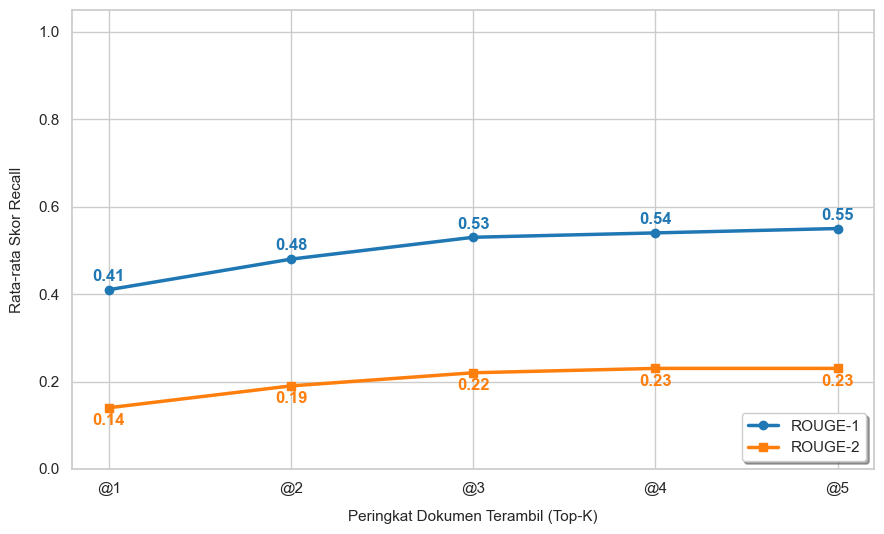

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. MENYIAPKAN DATA X DAN Y
# =====================================================================
# Sumbu X adalah peringkat dokumen
ks = list(avg_score_r1.keys())  # ['@1', '@2', '@3', '@4', '@5']

# Sumbu Y adalah nilai masing-masing metrik
r1_values = list(avg_score_r1.values())
r2_values = list(avg_score_r2.values())

# =====================================================================
# 2. PROSES VISUALISASI LINE CHART
# =====================================================================
sns.set_theme(style="whitegrid")  # Menggunakan background grid agar mudah dibaca
plt.figure(figsize=(9, 5.5))

# Plot Garis untuk ROUGE-1
plt.plot(
    ks, 
    r1_values, 
    marker='o',         # Titik lingkaran di setiap @K
    linewidth=2.5, 
    color='#1f77b4',    # Warna biru murni
    label='ROUGE-1'
)

# Plot Garis untuk ROUGE-2
plt.plot(
    ks, 
    r2_values, 
    marker='s',         # Titik kotak (square) di setiap @K agar beda bentuk
    linewidth=2.5, 
    color='#ff7f0e',    # Warna jingga
    label='ROUGE-2'
)

# =====================================================================
# 3. MENAMBAHKAN ANOTASI ANGKA DI SETIAP TITIK
# =====================================================================
# Anotasi untuk ROUGE-1
for i, val in enumerate(r1_values):
    plt.text(i, val + 0.02, f"{val:.2f}", ha='center', fontweight='bold', color='#1f77b4')

# Anotasi untuk ROUGE-2
for i, val in enumerate(r2_values):
    plt.text(i, val - 0.04, f"{val:.2f}", ha='center', fontweight='bold', color='#ff7f0e')

# =====================================================================
# 4. PENGATURAN LABELLING DAN ESTETIKA
# =====================================================================
# plt.title("Analisis Tren Performa Retrieval: ROUGE-1 vs ROUGE-2 dari @1 hingga @5", fontsize=13, pad=20, fontweight='bold')
plt.xlabel("Peringkat Dokumen Terambil (Top-K)", fontsize=11, labelpad=10)
plt.ylabel("Rata-rata Skor Recall", fontsize=11, labelpad=10)

plt.ylim(0.0, 1.05) # Membatasi sumbu Y dari 0 sampai maksimal skor 1 (dilebihkan dikit untuk teks)
plt.legend(loc="lower right", frameon=True, shadow=True) # Menampilkan legenda di kanan bawah

plt.tight_layout()
plt.show()

## Pengujian Data Akademik Mahasiswa (Sparse Method)

In [98]:
data_akademik = [
    '/Users/a/Programming/Langchain-Project/external-data/sintetik-data-akademik-mahasiswa (3).xlsx'
]

### Processing document

In [99]:
from typing import Iterator
from langchain_core.document_loaders import BaseLoader
from langchain_core.documents import Document as LCDocument
from docling.document_converter import DocumentConverter

In [100]:
class DoclingLoader(BaseLoader):
    def __init__(self, file_path: str | list[str]) -> None:
        self._file_paths = file_path if isinstance(file_path, list) else [file_path]
        self._converter = DocumentConverter()

    def lazy_load(self) -> Iterator[LCDocument]:
        for source in self._file_paths:
            dl_doc = self._converter.convert(source).document
            text = dl_doc.export_to_markdown()
            yield LCDocument(page_content=text)

In [101]:
loader = DoclingLoader(data_akademik)

docs_akademik = loader.lazy_load()

In [73]:
data_akademik_split = text_splitter.split_documents(docs_akademik)

2026-05-28 16:16:41,136 - INFO - detected formats: [<InputFormat.XLSX: 'xlsx'>]


2026-05-28 16:16:41,201 - INFO - Going to convert document batch...
2026-05-28 16:16:41,203 - INFO - Initializing pipeline for SimplePipeline with options hash 995a146ad601044538e6a923bea22f4e
2026-05-28 16:16:41,206 - INFO - Processing document sintetik-data-akademik-mahasiswa (3).xlsx
2026-05-28 16:16:41,209 - INFO - Processing sheet 0: Sheet1
2026-05-28 16:16:41,238 - INFO - Finished converting document sintetik-data-akademik-mahasiswa (3).xlsx in 0.13 sec.


In [188]:
vector_store_sparse = ElasticsearchStore(
    es_url="http://localhost:9200",
    index_name="data-akademik-index",
    es_user="elastic",
    es_password="Xkhwf3uB",
    strategy=ElasticsearchStore.BM25RetrievalStrategy(),
)

In [ ]:
vector_store_sparse.add_documents(data_akademik_split)

In [189]:
vector_store_sparse.similarity_search("Jihan Fahira")

[Document(metadata={}, page_content='| 112023035 | Gatot Subroto        | L               | Teknik Informatika |       2023 |          2 |  3.5  |          38 | Aktif             | Dr. Budi Santoso M.Kom  |\n| 112023036 | Hana Pertiwi         | P               | Sistem Informasi   |       2023 |          2 |  3.75 |          40 | Aktif             | Rina Wati M.T.          |\n| 112023037 | Iqbal Ramadhan       | L               | Teknik Informatika |       2023 |          2 |  3.7  |          42 | Aktif             | Siti Aminah M.T.        |\n| 112023038 | Jihan Fahira         | P               | Bisnis Digital     |       2023 |          2 |  3.95 |          44 | Aktif             | Agus Pratama M.Kom      |\n| 112023039 | Kiki Amalia          | L               | Teknik Informatika |       2023 |          2 |  3.6  |          40 | Aktif             | Dr. Budi Santoso M.Kom  |'),
 Document(metadata={}, page_content='| 112022135 | Ihsan Kamil          | L               | Sistem Informa

In [ ]:
data_uji_akademik_mahasiswa = {
    "Siapa nama mahasiswa dengan NIM 112022001?": "Ahmad Yusuf",
    "Berapa IPK dari Siti Aminah?": "3.85",
    "Apa Program Studi Budi Setiawan?": "Teknik Informatika",
    "Berapa SKS Lulus yang dimiliki oleh Dewi Lestari?": "84",
    "Apa Status Akademik Rizky Pratama?": "Aktif",
    "Siapa dosen pembimbing Ayu Wandira?": "Rina Wati M.T.",
    "Apa jenis kelamin dari Dimas Anggara?": "L",
    "Angkatan tahun berapakah Putri Maharani?": "2022",
    "Mahasiswa dengan NIM 112022009 sedang berada di semester berapa?": "4",
    "Siapa nama mahasiswa dengan NIM 112022010?": "Nisa Rahmawati",
    "Berapa IPK dari Bayu Kurniawan?": "3.5",
    "Apa Program Studi Dina Fitriani?": "Bisnis Digital",
    "Berapa SKS Lulus yang dimiliki oleh Hendra Wijaya?": "115",
    "Apa Status Akademik Rina Sari?": "Aktif",
    "Siapa dosen pembimbing Aditya Saputra?": "Dr. Budi Santoso M.Kom",
    "Apa jenis kelamin dari Indah Permatasari?": "P",
    "Angkatan tahun berapakah Kevin Sanjaya?": "2021",
    "Mahasiswa dengan NIM 112021018 sedang berada di semester berapa?": "6",
    "Siapa nama mahasiswa dengan NIM 112021019?": "Rian Ardiansyah",
    "Berapa IPK dari Rani Mulyani?": "3.9",
    "Apa Program Studi Aris Munandar?": "Teknik Informatika",
    "Berapa SKS Lulus yang dimiliki oleh Sari Wulandari?": "140",
    "Apa Status Akademik Gilang Ramadhan?": "Aktif",
    "Siapa dosen pembimbing Wahyuni Safitri?": "Ferry Irawan M.B.A.",
    "Apa jenis kelamin dari Irvan Hakim?": "L",
    "Angkatan tahun berapakah Lia Amalia?": "2020",
    "Mahasiswa dengan NIM 112020027 sedang berada di semester berapa?": "8",
    "Siapa nama mahasiswa dengan NIM 112020028?": "Tika Yuliana",
    "Berapa IPK dari Surya Lesmana?": "3.6",
    "Apa Program Studi Vina Panduwinata?": "Sistem Informasi",
    "Berapa SKS Lulus yang dimiliki oleh Candra Wijaya?": "42",
    "Apa Status Akademik Desi Ratnasari?": "Aktif",
    "Siapa dosen pembimbing Eko Prasetyo?": "Siti Aminah M.T.",
    "Apa jenis kelamin dari Fitriani Ningsih?": "P",
    "Angkatan tahun berapakah Gatot Subroto?": "2023",
    "Mahasiswa dengan NIM 112023036 sedang berada di semester berapa?": "2",
    "Siapa nama mahasiswa dengan NIM 112023037?": "Hana Pertiwi",
    "Berapa IPK dari Iqbal Ramadhan?": "3.7",
    "Apa Program Studi Jihan Fahira?": "Bisnis Digital",
    "Berapa SKS Lulus yang dimiliki oleh Kiki Amalia?": "40",
    "Apa Status Akademik Larasati Putri?": "Aktif",
    "Siapa dosen pembimbing Mahendra Putra?": "Dr. Budi Santoso M.Kom",
    "Apa jenis kelamin dari Nanda Aulia?": "P",
    "Angkatan tahun berapakah Okan Kornelius?": "2022",
    "Mahasiswa dengan NIM 112022044 sedang berada di semester berapa?": "4",
    "Siapa nama mahasiswa dengan NIM 112022045?": "Qori Akbar",
    "Berapa IPK dari Resti Fauziah?": "3.9",
    "Apa Program Studi Satria Tama?": "Teknik Informatika",
    "Berapa SKS Lulus yang dimiliki oleh Tantri Syalindri?": "80",
    "Apa Status Akademik Umar Hapsoro?": "Aktif",
    "Siapa dosen pembimbing Vivi Haryati?": "Agus Pratama M.Kom",
    "Apa jenis kelamin dari Wira Sentosa?": "L",
    "Angkatan tahun berapakah Xena Wulandari?": "2021",
    "Mahasiswa dengan NIM 112021053 sedang berada di semester berapa?": "6",
    "Siapa nama mahasiswa dengan NIM 112021054?": "Zalfa Nabila",
    "Berapa IPK dari Andi Firmansyah?": "3.4",
    "Apa Program Studi Bella Saphira?": "Sistem Informasi",
    "Berapa SKS Lulus yang dimiliki oleh Coki Sihotang?": "122",
    "Apa Status Akademik Dinda Hauw?": "Aktif",
    "Siapa dosen pembimbing Erwin Gutawa?": "Dr. Budi Santoso M.Kom",
    "Apa jenis kelamin dari Farida Pasha?": "P",
    "Angkatan tahun berapakah Gading Marten?": "2020",
    "Mahasiswa dengan NIM 112020061 sedang berada di semester berapa?": "8",
    "Siapa nama mahasiswa dengan NIM 112020062?": "Hesti Purwadinata",
    "Berapa IPK dari Indra Bekti?": "3.45",
    "Apa Program Studi Julia Perez?": "Sistem Informasi",
    "Berapa SKS Lulus yang dimiliki oleh Kaesang Pangarep?": "144",
    "Apa Status Akademik Luna Maya?": "Aktif",
    "Siapa dosen pembimbing Mandra Naih?": "Dr. Wahyu Hidayat M.Kom",
    "Apa jenis kelamin dari Nia Ramadhani?": "P",
    "Angkatan tahun berapakah Omesh Ananda?": "2020",
    "Mahasiswa dengan NIM 112020069 sedang berada di semester berapa?": "8",
    "Siapa nama mahasiswa dengan NIM 112020070?": "Paula Verhoeven",
    "Berapa IPK dari Rafi Ahmad?": "3.55",
    "Apa Program Studi Syahnaz Sadiqah?": "Sistem Informasi",
    "Berapa SKS Lulus yang dimiliki oleh Tora Sudiro?": "36",
    "Apa Status Akademik Ussy Sulistiawaty?": "Aktif",
    "Siapa dosen pembimbing Vino Bastian?": "Dr. Budi Santoso M.Kom",
    "Apa jenis kelamin dari Wulan Guritno?": "P",
    "Angkatan tahun berapakah Yayan Ruhian?": "2023",
    "Mahasiswa dengan NIM 112023077 sedang berada di semester berapa?": "2",
    "Siapa nama mahasiswa dengan NIM 112023078?": "Zaskia Adya Mecca",
    "Berapa IPK dari Ammar Zoni?": "3.5",
    "Apa Program Studi Bunga Citra Lestari?": "Sistem Informasi",
    "Berapa SKS Lulus yang dimiliki oleh Chicco Jerikho?": "80",
    "Apa Status Akademik Dian Sastrowardoyo?": "Aktif",
    "Siapa dosen pembimbing Fedi Nuril?": "Siti Aminah M.T.",
    "Apa jenis kelamin dari Gisel Anastasia?": "P",
    "Angkatan tahun berapakah Herjunot Ali?": "2022",
    "Mahasiswa dengan NIM 112022086 sedang berada di semester berapa?": "4",
    "Siapa nama mahasiswa dengan NIM 112022087?": "Jefri Nichol",
    "Berapa IPK dari Raisa Andriana?": "3.8",
    "Apa Program Studi Nicholas Saputra?": "Teknik Informatika",
    "Berapa SKS Lulus yang dimiliki oleh Maudy Ayunda?": "88",
    "Apa Status Akademik Reza Rahadian?": "Aktif",
    "Siapa dosen pembimbing Tara Basro?": "Rina Wati M.T.",
    "Apa jenis kelamin dari Joe Taslim?": "L",
    "Angkatan tahun berapakah Chelsea Islan?": "2021",
    "Mahasiswa dengan NIM 112021094 sedang berada di semester berapa?": "6",
    "Siapa nama mahasiswa dengan NIM 112021095?": "Iko Uwais"
}

In [ ]:
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_rouge_at_k(retrieved_document, ground_truth, max_k=5):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2'], use_stemmer=False)
    gt_text = str(ground_truth).lower()

    
    r1_scores_at_k = {}
    r2_scores_at_k = {}
    
    max_r1 = 0.0
    max_r2 = 0.0
    
    for i in range(1, max_k + 1):
        if i <= len(retrieved_document):
            doc_content = retrieved_document[i-1].page_content.lower()
            scores = scorer.score(gt_text, doc_content)
            
            # Ambil recall secara terpisah
            r1_recall = scores['rouge1'].recall
            r2_recall = scores['rouge2'].recall
            
            if r1_recall > max_r1:
                max_r1 = r1_recall
            if r2_recall > max_r2:
                max_r2 = r2_recall
                
        r1_scores_at_k[f"@{i}"] = max_r1
        r2_scores_at_k[f"@{i}"] = max_r2
        
    return r1_scores_at_k, r2_scores_at_k

In [ ]:
# 1. Inisialisasi penampung global terpisah untuk ROUGE-1 dan ROUGE-2
all_scores_r1 = {"@1": [], "@2": [], "@3": [], "@4": [], "@5": []}
all_scores_r2 = {"@1": [], "@2": [], "@3": [], "@4": [], "@5": []}

for question, gt in data_uji_akademik_mahasiswa.items():
    # Ambil 5 dokumen dari Elasticsearch BM25
    retrieved_documents = vector_store_sparse.similarity_search(question, k=5)

    # 2. Tangkap dua output dari fungsi baru (unpacking tuple)
    query_score_r1, query_score_r2 = evaluate_rouge_at_k(retrieved_documents, gt, max_k=5)

    # 3. Masukkan skor masing-masing ke penampung yang sesuai
    for k in all_scores_r1.keys():
        all_scores_r1[k].append(query_score_r1[k])
        all_scores_r2[k].append(query_score_r2[k])


# 4. Hitung rata-rata secara terpisah
avg_score_r1 = {}
avg_score_r2 = {}

for k in all_scores_r1.keys():
    avg_score_r1[k] = round(sum(all_scores_r1[k]) / len(all_scores_r1[k]), 2)
    avg_score_r2[k] = round(sum(all_scores_r2[k]) / len(all_scores_r2[k]), 2)


# 5. Print hasil keduanya
print(f"Hasil ROUGE-1 (Recall): {avg_score_r1}")
print(f"Hasil ROUGE-2 (Recall): {avg_score_r2}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. MENYIAPKAN DATA X DAN Y
# =====================================================================
# Sumbu X adalah peringkat dokumen
ks = list(avg_score_r1.keys())  # ['@1', '@2', '@3', '@4', '@5']

# Sumbu Y adalah nilai masing-masing metrik
r1_values = list(avg_score_r1.values())
r2_values = list(avg_score_r2.values())

# =====================================================================
# 2. PROSES VISUALISASI LINE CHART
# =====================================================================
sns.set_theme(style="whitegrid")  # Menggunakan background grid agar mudah dibaca
plt.figure(figsize=(9, 5.5))

# Plot Garis untuk ROUGE-1
plt.plot(
    ks, 
    r1_values, 
    marker='o',         # Titik lingkaran di setiap @K
    linewidth=2.5, 
    color='#1f77b4',    # Warna biru murni
    label='ROUGE-1'
)

# Plot Garis untuk ROUGE-2
plt.plot(
    ks, 
    r2_values, 
    marker='s',         # Titik kotak (square) di setiap @K agar beda bentuk
    linewidth=2.5, 
    color='#ff7f0e',    # Warna jingga
    label='ROUGE-2'
)

# =====================================================================
# 3. MENAMBAHKAN ANOTASI ANGKA DI SETIAP TITIK
# =====================================================================
# Anotasi untuk ROUGE-1
for i, val in enumerate(r1_values):
    plt.text(i, val + 0.02, f"{val:.2f}", ha='center', fontweight='bold', color='#1f77b4')

# Anotasi untuk ROUGE-2
for i, val in enumerate(r2_values):
    plt.text(i, val - 0.04, f"{val:.2f}", ha='center', fontweight='bold', color='#ff7f0e')

# =====================================================================
# 4. PENGATURAN LABELLING DAN ESTETIKA
# =====================================================================
# plt.title("Analisis Tren Performa Retrieval: ROUGE-1 vs ROUGE-2 dari @1 hingga @5", fontsize=13, pad=20, fontweight='bold')
plt.xlabel("Peringkat Dokumen Terambil (Top-K)", fontsize=11, labelpad=10)
plt.ylabel("Rata-rata Skor Recall", fontsize=11, labelpad=10)

plt.ylim(0.0, 1.05) # Membatasi sumbu Y dari 0 sampai maksimal skor 1 (dilebihkan dikit untuk teks)
plt.legend(loc="lower right", frameon=True, shadow=True) # Menampilkan legenda di kanan bawah

plt.tight_layout()
plt.show()

## Permodelan (LLM)

In [190]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_core.tools import tool
import operator
from langchain_core.messages import AIMessage

### Tools 

In [191]:

@tool
def query_from_academic_rule(query: str):
    """
    Gunakan tool ini untuk query dari user yang HANYA bermaksud untuk pertanyaan seputar ATURAN, KEBIJAKAN, SYARAT, atau PROSEDUR KAMPUS.
    
    args: 
        query: Search terms to look for
    """
    try:
        docs = vector_store.similarity_search(query, k=3)

        if not docs:
            return "Maaf, tidak ditemukan informasi relevan di data pedoman akademik."
        
        formatted_results = "\n\n---\n\n".join([d.page_content for d in docs])
        return f"Ditemukan informasi berikut dari Pedoman Akademik:\n{formatted_results}"
    
    except Exception as e:
        return "Terjadi Kesalahan saat mengakses vector database"


@tool
def get_student_academic_record(query: str):
    """
    Gunakan tool ini untuk mencari DATA PRIBADI MAHASISWA tertentu.
    Gunakan Atribut mahasiswa seperti (nama mahasiswa, NIM, status, Dosen Pembimbing) sebagai query pencarian.
    
    Args:
        query: Search terms to look for
    """
    try:
        docs = vector_store_sparse.similarity_search(query)

        if not docs:
            return "Maaf, tidak ditemukan informasi relevan di data akademik mahasiswa"
        
        formatted_results = "\n\n---\n\n".join([d.page_content for d in docs])
        return f"Ditemukan informasi berikut dari data akademik mahasiswa:\n{formatted_results}"
    
    except Exception as e:
        return "Terjadi kesalahn saat mengakses data akademik"

In [192]:
# Entry point (pintu masuk system)
system_prompt_cot = """
You are an intelligent Intent Router for the STT-NF Academic System. 
Your goal is to decide which tool(s) are required to answer the user's query accurately.

AVAILABLE TOOLS:
1. `query_from_academic_rule`: For General Regulations, Procedures, Requirements (Cuti, Sidang, KRS, etc).
2. `get_student_academic_record`: For Specific Student Identity (Name, NIM), Grades, IPK, Status.

OUTPUT FORMAT RULES:
1. IF you need a tool: Output a valid JSON object in the 'Action' step.
   Format: {"name": "tool_name", "args": {"argument_name": "value"}}
2. IF NO tool is needed (Greeting, Chit-chat, or OOT): Output the direct response text in **INDONESIAN**. Do not output JSON.
3. NEVER put a student's name (e.g., "Agus", "Budi") inside the `query_from_academic_rule` argument. The rulebook does NOT contain student names!

FEW-SHOT EXAMPLES:

EXAMPLE 1 (General Rule):
User: "Bagaimana prosedur mengajukan banding nilai ujian?"
Thought: The user is asking for the "prosedur" of "banding nilai". This is a general regulation.
Action: {"name": "query_from_academic_rule", "args": {"query": "prosedur banding nilai ujian"}}

EXAMPLE 2 (Specific Data):
User: "Cek status mahasiswa bernama Siti Aminah?"
Thought: The query explicitly mentions "Siti Aminah". I need to check individual status.
Action: {"name": "get_student_academic_record", "args": {"query": "Siti Aminah"}}

EXAMPLE 3 (Explicit Hybrid):
User: "Berapa jumlah SKS mahasiswa Agus Nasution, Dan dari pedoman akademik, apakah dia bisa lulus?"
Thought: User explicitly asks for specific data "SKS Agus Nasution" AND rule validation "syarat kelulusan". Need BOTH tools.
Action: [
    {"name": "get_student_academic_record", "args": {"query": "Agus Nasution"}},
    {"name": "query_from_academic_rule", "args": {"query": "syarat kelulusan SKS"}}
]

EXAMPLE 4 (Implicit Hybrid - LOGICAL DEDUCTION):
User: "Apakah Agus Nasution akan dikenakan SPP Progresif berdasarkan pedoman akademik?"
Thought: 
1. The query asks about applying a specific rule ("SPP Progresif") to a specific person ("Agus Nasution").
2. To evaluate this, I MUST know Agus's current status/semester (Requires `get_student_academic_record`).
3. I also MUST know the general rule for "SPP Progresif" (Requires `query_from_academic_rule`).
4. I must split this into two tool calls. I will NOT put Agus's name in the rule query.
Action: [
    {"name": "get_student_academic_record", "args": {"query": "Agus Nasution"}},
    {"name": "query_from_academic_rule", "args": {"query": "aturan syarat SPP Progresif"}}
]

EXAMPLE 5 (Greeting - Direct Response):
User: "Halo selamat malam"
Thought: Just a greeting. No tool needed. I must answer politely in Indonesian.
Action: Halo, selamat malam! Saya asisten akademik STT-NF. Ada yang bisa saya bantu terkait informasi akademik atau data mahasiswa?

INSTRUCTION:
Based on the logic above, determine the Thought and Action for the following user query.
"""

GENERATOR_PROMPT = """
PERAN:
Anda adalah Asisten Akademik Cerdas di kampus STT-NF (Sekolah Tinggi Terpadu Nurul Fikri).
Tugas Anda adalah menyusun jawaban akhir kepada pengguna dalam Bahasa Indonesia yang formal namun ramah.

INPUT ANDA:
1. Pertanyaan Asli User.
2. Data Mentah (JSON/Teks) dari hasil eksekusi alat (Context).

ATURAN MENJAWAB:
1. **GROUNDING:** Jawab HANYA berdasarkan data di `CONTEXT`. Jangan berhalusinasi.
2. **JIKA DATA DITEMUKAN:** Rangkum data tersebut menjadi kalimat yang enak dibaca.
   - Contoh: "Berdasarkan data, mahasiswa Tono (NIM 123) berstatus Aktif dengan IPK 3.8."
3. **JIKA DATA KOSONG/ERROR:** Katakan jujur: "Maaf, data tidak ditemukan. Mohon periksa nama atau NIM kembali."
4. **JANGAN** menampilkan struktur JSON mentah ke user.
5. **JANGAN** menyebutkan teknis internal (seperti "saya menggunakan tool get_student").

Silakan jawab pertanyaan user berdasarkan Context berikut.
"""

In [193]:
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[List[AnyMessage], add_messages]

In [194]:
import json
import re
import ast
from typing import Annotated, List, TypedDict, Optional

from langchain_core.messages import (
    AIMessage, 
    ToolMessage, 
    SystemMessage, 
    HumanMessage, 
    AnyMessage
)
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages

# --- 1. DEFINISI STATE ---
class AgentState(TypedDict):
    messages: Annotated[List[AnyMessage], add_messages]

# PROMPT KHUSUS GENERATOR (NODE 3) 
GENERATOR_PROMPT = """
PERAN:
Anda adalah Asisten Akademik Cerdas di kampus STT-NF (Sekolah Tinggi Terpadu Nurul Fikri).
Tugas Anda adalah menyusun jawaban akhir kepada pengguna dalam Bahasa Indonesia yang formal namun ramah.

ATURAN MENJAWAB:
1. **GROUNDING:** Jawab HANYA berdasarkan data di `CONTEXT`. Jangan berhalusinasi.
2. **KONDISI YA/TIDAK:** Pastikan jawaban Mengandung kata "YA" jika pernyataan/pertanyaan USER BENAR/MEMENUHI SYARAT, dan "TIDAK" jika pernyataan USER SALAH/TIDAK MEMENUHI SYARAT.
3. **JIKA DATA KOSONG/ERROR:** Katakan jujur: "Maaf, data tidak ditemukan. Mohon periksa nama atau NIM kembali."
4. **JANGAN** menampilkan struktur JSON mentah ke user.

PROSES BERPIKIR (WAJIB DIIKUTI SEBELUM MEMBERIKAN JAWABAN AKHIR):
Untuk menghindari kesalahan logika saat membaca data, jabarkan analisis Anda menggunakan format berikut:

[EKSTRAKSI DATA MAHASISWA]
- Tuliskan variabel yang relevan saja (contoh: IPK = ..., IPS = ..., SKS = ...). Jika tidak ada, tulis "Tidak ada".

[EKSTRAKSI ATURAN AKADEMIK]
- Tuliskan syarat aturannya (contoh: Syarat lulus IPK >= 2.00). Jika tidak ada, tulis "Tidak ada".

[ANALISIS LOGIKA]
- Bandingkan data mahasiswa dengan aturan akademik secara teliti. Pastikan Anda tidak tertukar antara IPS (Indeks Prestasi Semester) dan IPK (Indeks Prestasi Kumulatif).

[JAWABAN AKHIR]
- Tuliskan jawaban natural Anda di sini (Pastikan mengandung kata YA atau TIDAK sesuai hasil analisis).

INFORMASI DARI SISTEM (CONTEXT):
{context_data}

PERTANYAAN USER:
{user_query}
"""

# --- 3. CLASS AGENT UTAMA ---
class Agent:
    def __init__(self, model, tools, router_prompt=""):
        self.router_system = router_prompt
        self.tools = {t.name: t for t in tools}
        
        # Model 1: Router (Punya kemampuan bind tools)
        self.router_model = model.bind_tools(tools)
        
        # Model 2: Generator (Model polos untuk merangkai kata)
        self.generator_model = model 
        
        # --- DEFINISI GRAPH ---
        graph = StateGraph(AgentState)
        
        # Tambahkan Node
        graph.add_node("router", self.call_router)
        graph.add_node("tool_executor", self.take_action)
        graph.add_node("generator", self.run_generator)
        
        # Tentukan Entry Point
        graph.set_entry_point("router")
        
        # Edge Kondisional: Router -> (Tool Executor ATAU End)
        graph.add_conditional_edges( 
            "router", 
            self.exists_action, 
            {True: "tool_executor", False: END} 
        )
        
        # Edge Normal: Tool Executor -> Generator
        graph.add_edge("tool_executor", "generator")
        
        # Edge Normal: Generator -> End
        graph.add_edge("generator", END)
        
        self.graph = graph.compile()

    def _try_extract_tool_calls(self, content: str) -> List[dict]:
        if not content: return []
        
        # Bersihkan markdown
        content = re.sub(r'```json\s*', '', content)
        content = re.sub(r'```', '', content)
        
        extracted_tools = []
        
        # Coba cari format Array [...] dulu, kalau tidak ada baru cari Object {...}
        list_match = re.search(r'\[.*\]', content, re.DOTALL)
        dict_match = re.search(r'\{.*\}', content, re.DOTALL)
        
        candidates = []
        if list_match:
            candidates.append(list_match.group()) # Memasukkan [...]
        elif dict_match:
            candidates.append(dict_match.group()) # Memasukkan {...}
            
        for candidate in candidates:
            try:
                # loads akan berhasil karena formatnya sudah pasti [...] atau {...}
                data = json.loads(candidate)
                
                # Normalisasi: Jika yang didapat hanya 1 dict {...}, jadikan list [{...}]
                if isinstance(data, dict): 
                    data = [data]
                
                # Looping isi list untuk memvalidasi tools
                if isinstance(data, list):
                    for item in data:
                        if not isinstance(item, dict): continue
                        
                        name = item.get('name') or item.get('tool')
                        args = item.get('args') or item.get('arguments') or {}
                        
                        # Pastikan tool valid dan terdaftar
                        if name and name in self.tools:
                            extracted_tools.append({
                                'name': name,
                                'args': args,
                                'id': f"manual_{len(extracted_tools)}"
                            })
            except Exception as e:
                # Lanjut jika gagal parse (untuk menghindari sistem crash)
                continue 
                
        return extracted_tools

    # --- LOGIC: EXISTS ACTION ---
    def exists_action(self, state: AgentState) -> bool:
        result = state['messages'][-1]
        
        # 1. Cek Native Tool Calls
        if hasattr(result, "tool_calls") and len(result.tool_calls) > 0:
            return True
            
        # 2. Cek Manual Parsing
        if self._try_extract_tool_calls(result.content):
            print("🕵️ Valid JSON Action detected via regex.")
            return True
        
        return False

    # --- NODE 1: ROUTER ---
    def call_router(self, state: AgentState):
        messages = state["messages"]
        if self.router_system:
            if not isinstance(messages[0], SystemMessage):
                messages = [SystemMessage(content=self.router_system)] + messages
            else:
                messages[0] = SystemMessage(content=self.router_system)
        
        # 1. Panggil Model
        response = self.router_model.invoke(messages)
        content = response.content
        
        # 2. Cek apakah ini Tool Call (JSON)?
        # Kita gunakan helper yang sama untuk mendeteksi
        is_tool_call = False
        if hasattr(response, "tool_calls") and len(response.tool_calls) > 0:
            is_tool_call = True
        elif self._try_extract_tool_calls(content):
            is_tool_call = True
            
        # 3. LOGIKA CLEANING:
        # Jika BUKAN tool call (berarti Greeting/Chat biasa),
        # tapi ada format "Action:", kita potong text sebelumnya.
        if not is_tool_call and "Action:" in content:
            # Ambil teks setelah kata "Action:"
            clean_response = content.split("Action:")[-1].strip()
            
            # Update isi pesan agar user terima bersih
            response.content = clean_response
            
        return {'messages': [response]}

    # --- NODE 2: TOOL EXECUTOR ---
    def take_action(self, state: AgentState):
        llm_message = state['messages'][-1]
        tools_to_run = []
        
        if hasattr(llm_message, "tool_calls") and len(llm_message.tool_calls) > 0:
            tools_to_run = llm_message.tool_calls
        else:
            tools_to_run = self._try_extract_tool_calls(llm_message.content)

        results = []
        for tool_call in tools_to_run:
            tool_name = tool_call['name']
            tool_args = tool_call['args']
            tool_id = tool_call.get('id')

            print(f"🛠️ Executing: {tool_name} with {tool_args}") # Debug
            
            try:
                # Execute tool
                tool_output = self.tools[tool_name].invoke(tool_args)
            except Exception as e:
                tool_output = f"Error executing tool: {str(e)}"

            results.append(ToolMessage(
                tool_call_id=tool_id,
                name=tool_name,
                content=str(tool_output)
            ))

        return {"messages": results}

    # --- NODE 3: FINAL GENERATOR ---
    def run_generator(self, state: AgentState):
        messages = state['messages']
        
        # 1. Cari pertanyaan User yang asli
        user_query = "Unknown query"
        for msg in reversed(messages):
            if isinstance(msg, HumanMessage):
                user_query = msg.content
                break
        
        # 2. Siapkan Context
        context_data = ""

        for msg in reversed(messages):
            if isinstance(msg, ToolMessage):
                context_data += f"[{msg.name}]:\n{msg.content}\n\n"
            elif isinstance(msg, AIMessage):
                break
        
        if not context_data.strip():
            context_data = "Data Kosong."
            
        # 3. Buat Prompt untuk Generator
        final_prompt_content = f"""
        INFORMASI DARI SISTEM (CONTEXT):
        {context_data}
        
        PERTANYAAN USER:
        {user_query}
        """
        
        messages_for_generator = [
            SystemMessage(content=GENERATOR_PROMPT),
            HumanMessage(content=final_prompt_content)
        ]
        
        # 4. Invoke Model (Tanpa tools, pure generation)
        response = self.generator_model.invoke(messages_for_generator)
        raw_text = response.content
        
        # Bersihkan agar coret-coretan pikiran LLM tidak terlihat oleh user/sistem evaluasi
        if "[JAWABAN AKHIR]" in raw_text:
            clean_answer = raw_text.split("[JAWABAN AKHIR]")[-1].strip()
            response.content = clean_answer
            
        return {"messages": [response]}

### LLM model

In [202]:
from langchain_ollama import ChatOllama

In [203]:
model = ChatOllama(
    model="mistral:7b-instruct-v0.3-q8_0", 
    temperature=0, 
    streaming=True)

In [204]:
tools = [query_from_academic_rule, get_student_academic_record]

In [205]:
tools[1]

StructuredTool(name='get_student_academic_record', description='Gunakan tool ini untuk mencari DATA PRIBADI MAHASISWA tertentu.\nGunakan Atribut mahasiswa seperti (nama mahasiswa, NIM, status, Dosen Pembimbing) sebagai query pencarian.\n\nArgs:\n    query: Search terms to look for', args_schema=<class 'langchain_core.utils.pydantic.get_student_academic_record'>, func=<function get_student_academic_record at 0x13b4ea480>)

In [206]:
bot = Agent(model, tools, router_prompt=system_prompt_cot)

In [208]:
result = bot.graph.invoke({"messages": [HumanMessage(content="bisa bantu carikan informasi akademik dari mahasiswa Ahmad Yusuf")]})

🕵️ Valid JSON Action detected via regex.
🛠️ Executing: get_student_academic_record with {'query': 'Ahmad Yusuf'}


In [226]:
result

{'messages': [HumanMessage(content='bisa bantu carikan informasi akademik dari mahasiswa Ahmad Yusuf', additional_kwargs={}, response_metadata={}, id='9da966c3-1914-493f-a0c5-175bcd2d6113'),
  AIMessage(content=' Thought: The user is asking to find academic information about a specific student named "Ahmad Yusuf". I need to check individual data.\nAction: {"name": "get_student_academic_record", "args": {"query": "Ahmad Yusuf"}}', additional_kwargs={}, response_metadata={'model': 'mistral:7b-instruct-v0.3-q8_0', 'created_at': '2026-06-03T02:20:09.867615Z', 'done': True, 'done_reason': 'stop', 'total_duration': 31242854375, 'load_duration': 12907959500, 'prompt_eval_count': 1273, 'prompt_eval_duration': 10260865750, 'eval_count': 61, 'eval_duration': 8005407207, 'logprobs': None, 'model_name': 'mistral:7b-instruct-v0.3-q8_0', 'model_provider': 'ollama'}, id='lc_run--019e8b47-7cf5-7563-9689-573132ed4568-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1273, 'outpu

In [231]:
result['messages'][1].response_metadata

{'model': 'mistral:7b-instruct-v0.3-q8_0',
 'created_at': '2026-06-03T02:20:09.867615Z',
 'done': True,
 'done_reason': 'stop',
 'total_duration': 31242854375,
 'load_duration': 12907959500,
 'prompt_eval_count': 1273,
 'prompt_eval_duration': 10260865750,
 'eval_count': 61,
 'eval_duration': 8005407207,
 'logprobs': None,
 'model_name': 'mistral:7b-instruct-v0.3-q8_0',
 'model_provider': 'ollama'}

In [201]:
print(result['messages'][-1].content)

TypeError: list indices must be integers or slices, not str

## Pengujian Pipeline RAG secara keseluruhan

In [153]:
# fungsi Rouge untuk menghitung overlap N-gram

from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_system_response(system_response, ground_truth):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

    return scorer.score(system_response.lower(), ground_truth.lower())



In [ ]:
# fungsi untuk menggunakan mengambil data uji, looping ke chatbot dan uji dengan fungsi evaluate

testset = {
    "Berdasarkan pedoman kelulusan, apakah Sari Wulandari yang memiliki 140 SKS sudah bisa dinyatakan lulus dari program Sarjana?" : "Belum bisa. Meskipun Sari Wulandari sudah menempuh banyak SKS, syarat minimum beban studi untuk kelulusan program Sarjana adalah sekurang-kurangnya 148 SKS.",
    "Berapakah IPK dari Siti Aminah, dan apakah nilai tersebut sudah melewati batas minimal kelulusan akademik?": "IPK Siti Aminah adalah 3.85. Nilai ini sudah melewati batas minimal kelulusan akademik yang mensyaratkan IPK paling rendah 2.00.",
    "Jika Lia Amalia adalah mahasiswa angkatan 2020, berapa sisa masa studi maksimal yang dimilikinya sebelum terancam sanksi Drop Out?": "Masa studi maksimal program Sarjana adalah 7 tahun (14 semester). Karena Lia Amalia adalah angkatan 2020, maka batas akhir masa studinya adalah hingga tahun 2027 (semester 14).",
    "Apakah mahasiswa bernama Candra Wijaya dengan total 42 SKS sudah diperbolehkan untuk mengambil mata kuliah Tugas Akhir atau skripsi?" : "Belum diperbolehkan. Tugas Akhir merupakan syarat akhir kelulusan yang diambil setelah mahasiswa menyelesaikan sebagian besar beban studi. Dengan baru mengumpulkan 42 SKS, Candra Wijaya belum memenuhi kriteria kelayakan akademik untuk menempuh skripsi.",
    "Rani Mulyani memiliki IPK sebesar 3.9. Apakah nilai IPK tersebut sudah memenuhi standar minimum kelulusan yang ditetapkan kampus?": "Ya, sangat memenuhi. Batas minimum Indeks Prestasi Kumulatif (IPK) yang disyaratkan untuk bisa menyelesaikan program sarjana adalah paling rendah 2.00.",
    "Siapa nama dosen pembimbing dari mahasiswa Teknik Informatika yang bernama Aris Munandar?": "Berdasarkan data akademik mahasiswa, dosen pembimbing dari Aris Munandar belum tercantum pada potongan data yang tersedia (data hanya menunjukkan bahwa ia berada di Program Studi Teknik Informatika).",
    "Mahasiswa dengan NIM 112020027 saat ini sedang berada di semester 8. Surat resmi apa yang akan ia terima dari pihak kampus jika masa studinya terus berjalan hingga tahun keenam?": "Mahasiswa tersebut akan menerima surat teguran resmi dari pihak kampus (BAAK) ketika masa kuliahnya sudah berjalan 6 tahun sebagai peringatan menjelang habisnya masa perpanjangan studi.",
    "Berapa jumlah SKS Lulus yang dimiliki oleh Dewi Lestari saat ini?": "Berdasarkan data akademik, Dewi Lestari saat ini memiliki 84 SKS Lulus.",
    "Siapakah nama mahasiswa yang memiliki NIM 112022010 dan berapakah sisa waktu studi normalnya jika ia berada di angkatan 2022?" : "Mahasiswa dengan NIM 112022010 adalah Nisa Rahmawati. Sebagai angkatan 2022, masa studi maksimalnya (14 semester/7 tahun) akan berakhir pada tahun 2029.",
    "Apa program studi dari Jihan Fahira dan siapa dosen pembimbingnya": "Jihan Fahira berada di Program Studi Bisnis Digital, sedangkan dosen pembimbingnya adalah Agus Pratama M.Kom"
    }

testset_batch_2 = {
    "Kapan batas akhir pelunasan biaya kuliah bagi mahasiswa, dan bagaimana status dana tersebut apabila terjadi kelebihan bayar transfer?": "Biaya kuliah sudah harus dilunasi sebelum pelaksanaan Ujian Akhir Semester (UAS). Jika terjadi kelebihan pembayaran, dana tidak dapat ditarik kembali secara tunai melainkan akan diperhitungkan otomatis untuk pembayaran biaya kuliah di semester berikutnya.",
    "Langkah apa saja yang harus ditempuh oleh seorang mahasiswa jika terpaksa ingin mengajukan penundaan pembayaran uang semester?":"Mahasiswa wajib berkonsultasi terlebih dahulu dengan Dosen Pembimbing Akademik (PA). Kemudian, ia harus mengunduh dan mengisi form penundaan pembayaran (berisi rencana, waktu, dan jumlah bayar) serta melengkapinya dengan tanda tangan persetujuan orang tua/wali dan Dosen PA.",
    "Raisa Andriana merupakan mahasiswa Teknik Informatika yang memiliki IPK 3.8. Jika dilihat dari parameter nilai indeks prestasinya, apakah ia lolos batas minimal kelulusan akademik?":"Ya, sangat lolos. Pedoman akademik kampus menetapkan kriteria kelulusan program sarjana mewajibkan mahasiswa meraih nilai Indeks Prestasi Kumulatif (IPK) minimal 2.00. Nilai IPK Raisa Andriana yang mencapai 3.8 sudah jauh melampaui batas ambang kelayakan tersebut.",
    "Bagaimana rekam jejak awal berdirinya STT-NF pada tahun 1994 hingga akhirnya resmi diakui pemerintah sebagai institusi perguruan tinggi formal pada tahun 2012?": "STT-NF diawali tahun 1994 dengan berdirinya lembaga kursus NF Computer (NCS). Lembaga ini berganti nama menjadi LPK-NF (2000) dan LP3T-NF. Karena tingginya minat industri, Yayasan Profesi Terpadu Nurul Fikri didirikan (2009) dan mengajukan izin formal, hingga akhirnya resmi berdiri sebagai Sekolah Tinggi pada 13 Agustus 2012 melalui SK Mendikbud No. 269/E/O/2012.",
    "Kapan saja pihak BAAK atau kampus berkewajiban mengeluarkan surat peringatan resmi terkait evaluasi masa studi kepada mahasiswa yang bermasalah?": "Surat peringatan akan diberikan kepada mahasiswa pada tiga momentum: saat berakhirnya waktu studi terprogram, ketika masa studinya sudah berjalan 6 tahun, dan menjelang habisnya masa perpanjangan studi mereka.",
    "Kebijakan apa yang akan diberlakukan oleh pihak kampus terkait biaya kuliah bagi mahasiswa yang masa studinya telah melampaui waktu 4 tahun atau 8 semester?": "Bagi mahasiswa yang melampaui masa studi empat tahun atau setara dengan 8 semester, pihak STT Terpadu Nurul Fikri akan memberlakukan ketentuan tarif SPP Progresif (biaya kuliah berkala yang meningkat).",
    "Berdasarkan data akademik, Aditya Pratama adalah mahasiswa angkatan 2021 yang kini sudah berada di semester 10. Jika dihitung dari awal kuliah, apakah ia sudah mendekati batas masa studi maksimal yang ditetapkan kampus?":
        "Ya, Aditya Pratama yang berada di semester 10 sudah sangat mendekati batas maksimal masa studi. Ketentuan kampus menetapkan masa studi program Sarjana tidak boleh melebihi 14 semester atau 7 tahun, sehingga ia masih memiliki sisa 4 semester sebelum batas tersebut.",
    "Bayu Kurniawan adalah mahasiswa Teknik Informatika angkatan 2021 yang kini berada di semester 6. Berdasarkan ketentuan kampus, apakah ia sudah dikenakan SPP Progresif?":
        "Belum. Bayu Kurniawan yang berada di semester 6 belum dikenakan SPP Progresif. Ketentuan tersebut baru diberlakukan bagi mahasiswa yang masa kuliahnya melampaui 4 tahun atau lebih dari 8 semester.",
    "Seorang mahasiswa Bisnis Digital angkatan 2023 bernama Zaskia Adya Mecca memfoto catatan tugas teman sekelasnya lalu mengunggahnya ke media sosial tanpa izin. Apakah tindakan ini melanggar kode etik kampus?":
        "Ya, tindakan tersebut melanggar kode etik kampus. Berdasarkan Pasal 9 Kode Etik Mahasiswa, mahasiswa dilarang menyebarkan informasi pribadi milik orang lain di dunia maya tanpa memperoleh izin dari individu yang bersangkutan.",
    "Berapa kali minimal dalam satu semester mahasiswa seperti Ahmad Yusuf yang dibimbing oleh Dr. Budi Santoso M.Kom wajib melakukan konsultasi dengan dosen PA-nya?":
    "Berdasarkan pedoman, mahasiswa seperti Ahmad Yusuf diwajibkan melakukan bimbingan dengan Dosen Pembimbing Akademik (PA) sekurang-kurangnya 3 kali dalam setiap semester.",
    
}

testset_batch_3 = {
    "Zara Nugroho tercatat memiliki IPK 2.78 dengan 136 SKS dan statusnya masih Aktif. Apakah IPK tersebut cukup untuk memenuhi syarat kelulusan Sarjana di STT NF?":
        "Ya, IPK 2.78 milik Zara Nugroho sudah memenuhi syarat minimum IPK untuk kelulusan program Sarjana, yaitu paling rendah 2.00. Namun SKS-nya yang baru 136 belum memenuhi syarat minimum 148 SKS.",
    "Hendra Rahmawati adalah mahasiswa Teknik Informatika angkatan 2021 yang berada di semester 10 dengan status Cuti dan IPK 2.94. Apa risiko akademis yang mengancamnya jika tidak segera menyelesaikan studi?":
        "Hendra Rahmawati berisiko terkena Drop Out (DO) karena masa studinya sudah memasuki semester 10 dari batas maksimal 14 semester. Ditambah statusnya sedang Cuti, ia perlu segera aktif kembali dan menyelesaikan seluruh kewajiban akademis sebelum batas 14 semester habis, atau pihak kampus dapat menyatakan ia tidak mampu melanjutkan studi.",
    "Sandi Saraswati adalah mahasiswa Teknik Informatika angkatan 2021 yang sudah berada di semester 10. Apakah ia sudah terkena ketentuan SPP Progresif?":
        "Ya, Sandi Saraswati sudah terkena ketentuan SPP Progresif karena masa studinya telah melampaui 8 semester atau 4 tahun, yang merupakan batas mulai diberlakukannya skema biaya progresif tersebut.",
    "Vino Anggraini adalah mahasiswa Sistem Informasi angkatan 2021 yang kini di semester 10 dengan 144 SKS dan status Lulus. Apakah kondisinya memerlukan surat teguran dari kampus terkait masa studi?":
        "Tidak. Vino Anggraini tidak memerlukan surat teguran karena ia sudah berstatus Lulus, yang berarti seluruh kewajiban akademisnya telah terpenuhi sebelum melampaui batas masa studi yang ditetapkan.",
    "Wahyuni Safitri adalah mahasiswa Bisnis Digital angkatan 2020 dengan IPK 3.80, 144 SKS, dan status Lulus. Berdasarkan pedoman, tahapan apa yang harus dilaluinya sebelum bisa resmi menjadi wisudawan?":
        "Sebelum menjadi wisudawan, Wahyuni Safitri harus terlebih dahulu dinyatakan lulus melalui Sidang Yudisium yang diselenggarakan oleh Ketua Program Studi. Setelah itu, ia perlu mendaftar secara daring melalui https://alumni.nurulfikri.ac.id/ dan melunasi biaya wisuda melalui bank yang ditunjuk.",
    "Oktavia Ramadhani adalah mahasiswi Teknik Informatika yang berstatus Lulus dengan 144 SKS dan IPK 3.80. Dokumen pelengkap non-akademik apa yang sebaiknya ia urus setelah lulus untuk menunjang kariernya?":
        "Oktavia Ramadhani sebaiknya mengurus Surat Keterangan Pendamping Ijazah (SKPI), yaitu dokumen pelengkap yang memuat capaian non-akademik selama kuliah. SKPI bukan pengganti ijazah, namun berguna untuk menunjang karier dan kelayakan kerja di dunia industri.",
    "Jika Maudy Ayunda, mahasiswi Bisnis Digital angkatan 2022 dengan IPK sempurna 4.00, menyalin karya tulis temannya dan mengklaimnya sebagai tugas miliknya sendiri, pelanggaran apa yang ia lakukan berdasarkan pedoman kampus?":
        "Tindakan tersebut dikategorikan sebagai Plagiat, yaitu mengambil atau memakai ide, opini, atau karya tulis orang lain lalu mengakuinya sebagai milik pribadi tanpa memberi kredit atau atribusi kepada penciptanya. Hal ini jelas melanggar integritas akademik yang ditekankan dalam pedoman kampus.",
    "Elvina Damayanti adalah mahasiswi Bisnis Digital angkatan 2021 yang berstatus Lulus dan pernah mengikuti magang mandiri di luar mitra Dikti. Dokumen awal apa yang harus ia siapkan untuk proses konversi nilai?":
        "Elvina Damayanti harus menyiapkan Surat Pernyataan Mitra dan Surat Kesanggupan, keduanya dilengkapi tanda tangan basah serta cap basah khusus untuk mitra, kemudian dipindai. Kedua dokumen tersebut digabungkan menjadi satu file sebelum diunggah ke formulir di bit.ly/form-konversi.",
    "Berdasarkan data mahasiswa, siapa saja dari angkatan 2020 yang sudah berstatus Lulus, dan apakah mereka semua sudah memenuhi syarat minimum 148 SKS yang ditetapkan pedoman?":
        "Mahasiswa angkatan 2020 yang berstatus Lulus antara lain Wahyuni Safitri (144 SKS), Irvan Hakim (144 SKS), Tika Yuliana (144 SKS), Surya Lesmana (144 SKS), Vina Panduwinata (144 SKS), Julia Perez (144 SKS), Kaesang Pangarep (144 SKS), Nia Ramadhani (144 SKS), dan Paula Verhoeven (144 SKS). Berdasarkan data yang tercatat, SKS mereka berada di 144, yang perlu dikonfirmasi lebih lanjut apakah sudah memenuhi ketentuan minimum 148 SKS sesuai pedoman prodi masing-masing.",
    "Mahasiswa mana dari program Bisnis Digital yang sudah Lulus dan memiliki IPK di atas 3.80, dan apakah kelulusan mereka sudah sesuai dengan semua kriteria yang disebutkan dalam pedoman akademik?":
        "Mahasiswa Bisnis Digital yang sudah Lulus dengan IPK di atas 3.80 antara lain Tika Yuliana (IPK 3.85, 144 SKS), Paula Verhoeven (IPK 3.90, 144 SKS), Dina Fitriani (IPK 3.92, 122 SKS), Rani Mulyani (IPK 3.90, 122 SKS), dan beberapa lainnya. Untuk konfirmasi kelulusan penuh sesuai pedoman, perlu dipastikan mereka juga telah memiliki sertifikat kompetensi dan lulus mata kuliah Tugas Akhir, karena data yang tersedia hanya mencakup SKS dan IPK."

    
}

testset_batch_4 = {
    "Siapa nama mahasiswa dengan NIM 112022090, di program studi apa ia kuliah, dan berapa IPK-nya saat ini?":
        "Mahasiswa dengan NIM 112022090 adalah Maudy Ayunda, terdaftar di program studi Bisnis Digital angkatan 2022, dengan IPK sempurna 4.00.",

    "Berapakah total SKS yang sudah ditempuh oleh Bella Safitri dengan NIM 112022128, dan di semester berapa ia sekarang?":
        "Bella Safitri dengan NIM 112022128 saat ini berada di semester 8 dan sudah menempuh 142 SKS.",

    "Siapa dosen pembimbing akademik dari mahasiswa bernama Tuti Handayani yang merupakan mahasiswi Teknik Informatika angkatan 2023?":
        "Dosen Pembimbing Akademik Tuti Handayani adalah Dr. Wahyu Hidayat M.Kom.",

    "Joko Fitriani adalah mahasiswa Teknik Informatika angkatan 2022 dengan IPK 2.88 dan 141 SKS di semester 8. Berdasarkan pedoman kelulusan, apakah IPK-nya memenuhi syarat minimum?":
        "Ya, IPK 2.88 milik Joko Fitriani sudah memenuhi syarat minimum kelulusan program Sarjana yaitu IPK paling rendah 2.00. Namun SKS-nya yang baru 141 belum memenuhi syarat minimum 148 SKS.",

    "Amalia Dewanata adalah mahasiswi Bisnis Digital angkatan 2024 dengan IPK 2.84 dan status Aktif. Apakah IPK tersebut memenuhi syarat minimum kelulusan Sarjana di STT NF?":
        "Ya, IPK 2.84 milik Amalia Dewanata sudah memenuhi syarat minimum IPK kelulusan program Sarjana, yaitu paling rendah 2.00. Meski demikian, ia masih di semester awal sehingga masih banyak kewajiban lain yang harus dipenuhi sebelum bisa dinyatakan lulus.",
    
    "Dian Sari adalah mahasiswi Sistem Informasi angkatan 2022 semester 8 yang sudah berstatus Lulus dengan 144 SKS dan IPK 2.97. Apakah kelulusannya sudah sah meskipun IPK-nya rendah?":
        "Ya, kelulusan Dian Sari sah secara akademis karena IPK 2.97 sudah berada di atas batas minimum 2.00 yang ditetapkan pedoman. Statusnya yang tercatat Lulus menandakan seluruh persyaratan lainnya juga telah terpenuhi.",

    "Muhammad Sanjaya adalah mahasiswa Teknik Informatika angkatan 2023 yang kini berstatus Cuti di semester 6. Berdasarkan pedoman, apakah masa cutinya ikut dihitung dalam batas masa studi 14 semester?":
        "Ya, berdasarkan ketentuan kampus, masa cuti Muhammad Sanjaya tetap dihitung dalam perhitungan masa studi maksimal 14 semester. Cuti tidak menghentikan jalannya hitungan batas 7 tahun tersebut.",

    "Krisna Mahendra adalah mahasiswa Teknik Informatika angkatan 2023 semester 6 yang berstatus Cuti dengan IPK 3.25 dan hanya 95 SKS. Apa yang harus ia prioritaskan setelah aktif kembali?":
        "Setelah aktif kembali, Krisna Mahendra harus memprioritaskan penambahan SKS secara signifikan karena dengan 95 SKS di semester 6, ia masih jauh dari batas minimum 148 SKS untuk lulus. Ia juga perlu menjaga IPK di atas 2.00 dan memastikan masa studinya tidak melampaui batas 14 semester.",
    
     "Coki Pratama adalah mahasiswa Teknik Informatika angkatan 2024 semester 4 yang berstatus Cuti dengan IPK 3.20 dan hanya 60 SKS. Berdasarkan pedoman SPP Progresif, apakah ia sudah terkena ketentuan tersebut?":
        "Belum. Coki Pratama yang baru berada di semester 4 belum terkena SPP Progresif. Ketentuan tersebut baru diberlakukan bagi mahasiswa yang masa kuliahnya melampaui 4 tahun atau lebih dari 8 semester.",

    "Uswatun Hasanah adalah mahasiswi Teknik Informatika angkatan 2022 di semester 8 dengan IPK 3.95, 144 SKS, dan berstatus Lulus. Tahapan administratif apa yang harus ia selesaikan untuk bisa menghadiri wisuda?":
        "Uswatun Hasanah harus terlebih dahulu dinyatakan lulus melalui Sidang Yudisium oleh Ketua Program Studi. Setelah itu, ia perlu mendaftarkan diri secara daring melalui https://alumni.nurulfikri.ac.id/ dan melunasi biaya wisuda melalui bank resmi yang ditunjuk kampus.",


}

testset_batch_5 = {
     "Nadia Shafira adalah mahasiswi Teknik Informatika angkatan 2022 semester 8 dengan IPK 3.85 dan 142 SKS berstatus Aktif. Berapa SKS lagi yang ia butuhkan agar memenuhi syarat minimum kelulusan?":
        "Nadia Shafira masih membutuhkan setidaknya 6 SKS lagi untuk memenuhi syarat minimum kelulusan, karena ia baru menempuh 142 SKS sedangkan batas minimum yang diwajibkan adalah 148 SKS.",

    "Taufik Rahman adalah mahasiswa Bisnis Digital angkatan 2022 semester 8 dengan IPK 3.80 dan 142 SKS berstatus Aktif. Selain menambah SKS, syarat kelulusan apa lagi yang perlu ia penuhi berdasarkan pedoman?":
        "Selain menambah SKS hingga minimal 148, Taufik Rahman juga harus memastikan ia lulus mata kuliah Tugas Akhir (skripsi) dan memiliki sertifikat kompetensi, serta menyelesaikan studi sebelum melampaui batas 14 semester.",

    "Bandingkan kondisi akademis Aisyah Nabila (NIM 112021102, semester 10, 140 SKS, IPK 3.65) dengan Aditya Pratama (NIM 112021101, semester 10, 138 SKS, IPK 3.45). Siapa yang lebih dekat memenuhi syarat kelulusan dari sisi SKS?":
        "Aisyah Nabila lebih dekat memenuhi syarat kelulusan dari sisi SKS. Ia sudah menempuh 140 SKS, hanya kurang 8 SKS dari batas minimum 148 SKS, sedangkan Aditya Pratama baru menempuh 138 SKS sehingga masih kurang 10 SKS.",

    "Di antara mahasiswa Bisnis Digital angkatan 2021 semester 10 yang masih Aktif, siapa yang memiliki SKS paling banyak dan sudah seberapa dekat dengan syarat kelulusan minimum 148 SKS?":
        "Di antara mahasiswa Bisnis Digital angkatan 2021 semester 10 yang masih Aktif, Qonita Sari memiliki SKS terbanyak yaitu 136 SKS, namun masih kurang 12 SKS dari syarat minimum 148 SKS. Disusul Bagus Setiawan dengan 135 SKS dan Tegar Saputra dengan 135 SKS.",

     "Gita Saraswati adalah mahasiswi Sistem Informasi angkatan 2021 semester 10 yang dibimbing oleh Rina Wati M.T. Berapa kali minimal ia wajib bertemu dosen PA-nya dalam satu semester berdasarkan pedoman?":
        "Berdasarkan pedoman kampus, Gita Saraswati wajib melakukan bimbingan dengan Dosen Pembimbing Akademik Rina Wati M.T. sekurang-kurangnya 3 kali dalam setiap semester.",

    "Berdasarkan pedoman evaluasi studi, pada momen apa saja mahasiswa seperti Fadli Nugroho yang berada di semester 10 angkatan 2021 akan dievaluasi secara khusus oleh kampus?":
        "Fadli Nugroho yang berada di semester 10 akan dievaluasi secara khusus pada akhir semester 8 (yang sudah dilaluinya), di bagian akhir program studi, serta pada masa menjelang habisnya batas waktu maksimal 14 semester. Selain itu, evaluasi rutin juga dilakukan di setiap akhir semester.",

    "Diana Larasati adalah mahasiswi Bisnis Digital angkatan 2022 semester 8 yang berstatus Lulus. Dokumen keuangan apa yang wajib ia miliki sebagai prasyarat mendaftar sidang skripsi dan kelulusan?":
        "Diana Larasati wajib memiliki Surat Keterangan Lunas Biaya Pendidikan sebagai prasyarat wajib untuk mendaftar sidang skripsi/tugas akhir serta keperluan administrasi kelulusan lainnya.",

    "Candra Wibowo adalah mahasiswa Sistem Informasi angkatan 2022 semester 8 yang berstatus Cuti. Berapa biaya yang harus ia bayarkan selama masa cutinya dan bagaimana mekanisme pembayarannya?":
        "Biaya cuti Candra Wibowo ditetapkan mengikuti tarif Biaya Semester atau BOP sesuai angkatannya. Pembayaran wajib dilakukan melalui transfer Virtual Account CIMB Niaga Syariah setelah mengisi formulir cuti dan sebelum periode cuti dimulai.",

    "Rizky Hidayat (NIM 112021233) adalah mahasiswa Bisnis Digital angkatan 2022 semester 8 yang berstatus Lulus dengan IPK 2.90 dan 144 SKS. Mengingat IPK-nya yang rendah, apakah ia tetap sah dinyatakan lulus berdasarkan pedoman kampus?":
        "Ya, Rizky Hidayat tetap sah dinyatakan lulus karena IPK 2.90 sudah memenuhi batas minimum kelulusan yaitu 2.00. Statusnya yang tercatat Lulus dalam sistem menunjukkan seluruh persyaratan akademis lainnya, termasuk penyelesaian Tugas Akhir dan kepemilikan sertifikat kompetensi, telah terpenuhi.",
    
    "Intan Anggraini adalah mahasiswi Sistem Informasi angkatan 2022 semester 8 dengan IPK 2.99 dan 141 SKS berstatus Aktif. Berdasarkan pedoman, apa saja yang masih harus ia penuhi dan risiko apa yang mengancam jika tidak segera diselesaikan?":
        "Intan Anggraini masih harus menambah minimal 7 SKS untuk mencapai 148 SKS, menyelesaikan Tugas Akhir, dan memiliki sertifikat kompetensi. Risiko yang mengancam adalah potensi kena SPP Progresif jika melewati semester 8, dan ancaman DO jika tidak mampu menyelesaikan semua kewajiban sebelum batas 14 semester habis.",
}

testset_batch_6 = {

    "Siapa mahasiswa dengan NIM 112021299, di program studi apa ia terdaftar, dan apa yang menarik dari data akademisnya?":
        "Mahasiswa dengan NIM 112021299 adalah Ihsan Yasmin, terdaftar di program studi Bisnis Digital angkatan 2024 semester 4. Yang menarik, ia memiliki IPK sempurna 4.00 namun berstatus Cuti dengan hanya 65 SKS.",

    "Siapa dosen pembimbing Zara Nugroho dengan NIM 112021245, dan berapa IPK serta SKS yang sudah ia tempuh?":
        "Dosen pembimbing Zara Nugroho adalah Dr. Wahyu Hidayat M.Kom. Ia memiliki IPK 2.78 dengan 136 SKS dan berstatus Aktif di semester 8.",

    "Sandi Wahyuni adalah mahasiswa Teknik Informatika angkatan 2021 semester 10 yang berstatus Cuti dengan IPK 2.82 dan 135 SKS. Berdasarkan pedoman, apakah IPK-nya memenuhi syarat minimum dan apa ancaman terbesar yang ia hadapi?":
        "IPK 2.82 milik Sandi Wahyuni sudah memenuhi syarat minimum kelulusan 2.00. Namun ancaman terbesarnya adalah masa studinya yang sudah di semester 10 dengan status Cuti, sehingga jika tidak segera aktif dan menyelesaikan kewajiban akademis, ia berisiko terkena Drop Out saat mendekati batas 14 semester.",

    "Hana Kurniawan adalah mahasiswi Sistem Informasi angkatan 2021 semester 10 yang berstatus Cuti dengan IPK 2.82 dan 132 SKS. Berapa SKS minimum yang masih harus ia kejar dan apa konsekuensi jika gagal menyelesaikannya sebelum semester 14?":
        "Hana Kurniawan masih harus menambah minimal 16 SKS untuk mencapai syarat minimum 148 SKS. Jika gagal menyelesaikan seluruh kewajiban akademis sebelum batas 14 semester, ia akan dinyatakan tidak mampu melanjutkan studi dan berstatus Drop Out (DO).",

    "Laras Putri adalah mahasiswi Teknik Informatika angkatan 2022 semester 8 yang berstatus Cuti dengan IPK 2.86 dan 131 SKS. Apakah ia sudah dikenakan SPP Progresif dan apa yang perlu ia lakukan terkait biaya kuliahnya selama cuti?":
        "Laras Putri belum dikenakan SPP Progresif karena berada tepat di semester 8, sedangkan ketentuan tersebut berlaku bagi yang melampaui 8 semester. Selama masa cuti, ia tetap wajib membayar biaya cuti sesuai tarif BOP angkatannya melalui Virtual Account CIMB Niaga Syariah sebelum periode cuti dimulai.",

    "Bandingkan kondisi akademis Vino Anggraini (NIM 112021255, Sistem Informasi, semester 10, 144 SKS, IPK 3.11, Lulus) dengan Ihsan Mariana (NIM 112021282, Sistem Informasi, semester 10, 124 SKS, IPK 3.03, Aktif). Apa perbedaan utama kondisi keduanya?":
        "Perbedaan utama keduanya adalah Vino Anggraini sudah berstatus Lulus dengan 144 SKS meskipun IPK-nya hanya 3.11, yang berarti seluruh kewajiban akademisnya sudah terpenuhi. Sebaliknya, Ihsan Mariana yang memiliki IPK serupa 3.03 masih berstatus Aktif dengan 124 SKS, sehingga masih perlu menambah minimal 24 SKS dan menyelesaikan kewajiban lainnya sebelum bisa dinyatakan lulus.",

    "Ervan Sanjaya adalah mahasiswa Bisnis Digital angkatan 2021 semester 10 yang berstatus Cuti dengan IPK 3.35 dan 127 SKS. Jika ia ingin mengajukan perpanjangan masa studi, syarat apa yang harus ia penuhi berdasarkan pedoman kampus?":
        "Berdasarkan pedoman, Ervan Sanjaya hanya bisa mendapat perpanjangan masa studi jika tinggal menyelesaikan Tugas Akhir/skripsi. Namun dengan 127 SKS, ia masih jauh dari kondisi tersebut karena belum memenuhi syarat minimum 148 SKS, sehingga pengajuan perpanjangan kemungkinan besar tidak akan dikabulkan.",

    "Gilang Saputra adalah mahasiswa Bisnis Digital angkatan 2022 yang kini berada di semester 8 dengan IPK 3.50 dan 130 SKS berstatus Aktif. Berdasarkan pedoman, evaluasi khusus apa yang akan ia hadapi di semester ini dan apa dampaknya?":
        "Di akhir semester 8, Gilang Saputra akan menghadapi evaluasi penentu hasil studi yang merupakan salah satu momen evaluasi khusus bagi mahasiswa S1. Hasil evaluasi ini akan menentukan batas SKS yang boleh diambil di semester berikutnya, dan jika performa akademisnya dinilai tidak memadai, kampus dapat mengambil langkah evaluasi lebih lanjut terkait kelanjutan studinya.",

    "Jihan Khairunnisa (NIM 112022136) adalah mahasiswi Bisnis Digital angkatan 2022 semester 8 yang berstatus Lulus dengan 144 SKS dan IPK 3.90. Jika ia belum mengisi formulir bebas biaya secara online, ke mana ia harus pergi untuk mendapatkan formulir tersebut dan berapa lama prosesnya?":
        "Jika tidak mengisi secara online, Jihan Khairunnisa dapat mengambil formulir cetak Surat Keterangan Lunas Biaya Pendidikan langsung di ruangan BAAK Kampus B2. Setelah diisi dan diserahkan ke Bagian Keuangan atau dikirim via email ke keuangan@nurulfikri.ac.id, surat keterangan tersebut akan diterbitkan paling lambat dalam waktu 3 hari kerja.",

    "Winda Rahmawati adalah mahasiswi Teknik Informatika angkatan 2021 semester 10 yang berstatus Aktif dengan IPK 3.79 dan 136 SKS. Jika ia tidak mampu menyelesaikan studinya hingga semester 14, prosedur apa yang akan dijalankan kampus dan dokumen apa yang masih bisa ia minta?":
        "Jika Winda Rahmawati tidak berhasil menyelesaikan studi hingga batas 14 semester, Kaprodi akan mengajukan surat usulan pengunduran diri beserta riwayat studi kepada Ketua. Setelah SK Drop Out terbit, SK tersebut dikirimkan ke orang tua atau wali bersama transkrip nilai. Meski sudah di-DO, ia masih diperbolehkan mengajukan permohonan surat keterangan lainnya yang dianggap perlu kepada pihak kampus.",
}

testset_batch_7 = {
    
}

In [254]:
testset = {
    "Berdasarkan pedoman kelulusan, apakah Sari Wulandari yang memiliki 140 SKS sudah bisa dinyatakan lulus dari program Sarjana?" : "Belum bisa. Meskipun Sari Wulandari sudah menempuh banyak SKS, syarat minimum beban studi untuk kelulusan program Sarjana adalah sekurang-kurangnya 148 SKS.",
}

In [164]:
test_dict = []
for pertanyaan, jawaban in testset.items():
    data_baru = {
        'pertanyaan': pertanyaan,
        'jawaban': jawaban
    }
    test_dict.append(data_baru)

In [262]:
test_dict

[{'pertanyaan': 'Berdasarkan pedoman kelulusan, apakah Sari Wulandari yang memiliki 140 SKS sudah bisa dinyatakan lulus dari program Sarjana?',
  'jawaban': 'Belum bisa. Meskipun Sari Wulandari sudah menempuh banyak SKS, syarat minimum beban studi untuk kelulusan program Sarjana adalah sekurang-kurangnya 148 SKS.'},
 {'pertanyaan': 'Berapakah IPK dari Siti Aminah, dan apakah nilai tersebut sudah melewati batas minimal kelulusan akademik?',
  'jawaban': 'IPK Siti Aminah adalah 3.85. Nilai ini sudah melewati batas minimal kelulusan akademik yang mensyaratkan IPK paling rendah 2.00.'}]

In [273]:
def pipeline_chatbot(data_uji):
    result = []
    for question, answer in data_uji.items():
        response = bot.graph.invoke({"messages": [HumanMessage(content=question)]})

        # hitung overlap N-gram antara respone dan answer
        test_set_result = {
                        'AiResponse' : response['messages'][-1].content,
                        'answer': answer,
                        'score' : evaluate_system_response(response['messages'][-1].content, answer)
                            }
        
        result.append(test_set_result)

    return result

In [168]:
test_result = pipeline_chatbot(testset)

🕵️ Valid JSON Action detected via regex.
🛠️ Executing: query_from_academic_rule with {'query': 'syarat kelulusan SKS'}
🛠️ Executing: get_student_academic_record with {'query': 'Sari Wulandari'}
🕵️ Valid JSON Action detected via regex.
🛠️ Executing: get_student_academic_record with {'query': 'Siti Aminah'}
🛠️ Executing: query_from_academic_rule with {'query': 'batas minimal kelulusan IPK'}


In [170]:
test_result[0]

{'AiResponse': 'Tidak dapat menyelesaikan, karena tidak ada informasi yang mengenai sertifikat kompetensi dan persyaratan-persyaratan lain yang telah dipenuhi oleh Sari Wulandari.',
 'answer': 'Belum bisa. Meskipun Sari Wulandari sudah menempuh banyak SKS, syarat minimum beban studi untuk kelulusan program Sarjana adalah sekurang-kurangnya 148 SKS.',
 'score': {'rouge1': Score(precision=0.09090909090909091, recall=0.09523809523809523, fmeasure=0.09302325581395349),
  'rouge2': Score(precision=0.047619047619047616, recall=0.05, fmeasure=0.04878048780487805),
  'rougeL': Score(precision=0.09090909090909091, recall=0.09523809523809523, fmeasure=0.09302325581395349)}}

In [171]:
test_result[1]

{'AiResponse': 'YA, nilai IPK dari Siti Aminah telah melewati batas minimal kelulusan akademik.',
 'answer': 'IPK Siti Aminah adalah 3.85. Nilai ini sudah melewati batas minimal kelulusan akademik yang mensyaratkan IPK paling rendah 2.00.',
 'score': {'rouge1': Score(precision=0.42857142857142855, recall=0.75, fmeasure=0.5454545454545454),
  'rouge2': Score(precision=0.25, recall=0.45454545454545453, fmeasure=0.3225806451612903),
  'rougeL': Score(precision=0.38095238095238093, recall=0.6666666666666666, fmeasure=0.4848484848484849)}}

## Pengujian per-batch 

In [ ]:
# pertimbangan untuk mendapatkan total token yang di input dan waktu response(response time)


In [274]:
# simpan hasil stress test beserta metada kedalam file json

import json
import os
from datetime import datetime

HASIL_FILE = "evaluation_result.json"

def load_existing_result()  -> dict:
    # load hasil sebelumnya jika ada
    if os.path.exists(HASIL_FILE):
        with open(HASIL_FILE, 'r', encoding='utf-8') as f:
            return json.load(f)
        
    return {
        "batches"           : [],
        "all_results"       : [],
        "all_failed"        : [],
        "system_failed"     : [],
        "total_batches_run" : 0
    }

def save_result(data: dict):
    with open(HASIL_FILE, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

### Kode dibawah dibuat untuk mengekstrak metadata dan juga hasil generate system

In [275]:
def extract_metadata(meta: dict) -> dict:
    total = meta.get("total_duration", 0)
    load     = meta.get('load_duration', 0)
    p_eval_d = meta.get('prompt_eval_duration', 0)
    eval_d   = meta.get('eval_duration', 0)
    eval_c   = meta.get('eval_count', 0)
    p_eval_c = meta.get('prompt_eval_count', 0)

    return {
        'total_duration_s'      : round(total / 1e9, 3),
        'load_duration_s'       : round(load / 1e9, 3),
        'prompt_eval_duration_s': round(p_eval_d / 1e9, 3),
        'eval_duration_s'       : round(eval_d / 1e9, 3),
        'prompt_token_count'    : p_eval_c,
        'output_token_count'    : eval_c,
        'tokens_per_second'     : round(eval_c / (eval_d / 1e9), 2) if eval_d > 0 else 0,
        'cold_start'            : load > 5_000_000_000,
    }


def score_to_dict(score) -> dict:
    """Konversi Rouge score object ke dict biasa (JSON serializable)."""
    return {k: {'precision': round(v.precision, 4),
                'recall'   : round(v.recall, 4),
                'fmeasure' : round(v.fmeasure, 4)}
            for k, v in score.items()}


In [276]:
# pipeline secara keseluruhan

def pipeline_chatbot_batch(data_uji: dict, threshold: float = 0.05):
    result          = []
    failed_result   = []
    system_failed   = []

    for question, answer in data_uji.items():
        try:
            response    = bot.graph.invoke({"messages": [HumanMessage(content=question)]})
            ai_response = response['messages'][-1].content

            # Ambil metadata dari response
            raw_meta    = response['messages'][1].response_metadata  # ['messages'][1].response_metadata
            metadata    = extract_metadata(raw_meta)

            score       = evaluate_system_response(ai_response, answer)
            is_failed   = score['rougeL'].fmeasure < threshold

            test_set_result = {
                'timestamp' : datetime.now().isoformat(),
                'question'  : question,
                'AiResponse': ai_response,
                'answer'    : answer,
                'score'     : score_to_dict(score),
                'is_failed' : is_failed,
                'metadata'  : metadata
            }

            if is_failed:
                failed_result.append(test_set_result)

            result.append(test_set_result)

        except Exception as e:
            print(f"⚠️  Gagal: '{question[:60]}' → {e}")
            system_failed.append({
                'timestamp' : datetime.now().isoformat(),
                'question'  : question,
                'AiResponse': None,
                'answer'    : answer,
                'is_failed' : True,
                'error'     : str(e)
            })

    def avg(key, metric):
        return round(sum(r['score'][key][metric] for r in result) / len(result), 4) if result else 0

    batch_summary = {
            'batch_index'   : None,  # diisi saat merge
            'jumlah_data'   : len(result),
            'jumlah_gagal'  : len(failed_result),
            'avg_recall'    : {'rouge1': avg('rouge1','recall'),  'rouge2': avg('rouge2','recall'),  'rougeL': avg('rougeL','recall')},
            'avg_precision' : {'rouge1': avg('rouge1','precision'),'rouge2': avg('rouge2','precision'),'rougeL': avg('rougeL','precision')},
            'avg_f1'        : {'rouge1': avg('rouge1','fmeasure'), 'rouge2': avg('rouge2','fmeasure'), 'rougeL': avg('rougeL','fmeasure')},
            'avg_tps'       : round(sum(r['metadata']['tokens_per_second'] for r in result) / len(result), 2) if result else 0,
            'cold_start_count': sum(r['metadata']['cold_start'] for r in result),
        }

    # Merge dengan hasil sebelumnya dan simpan
    existing = load_existing_result()
    batch_summary['batch_index'] = existing['total_batches_run'] + 1

    existing['batches'].append(batch_summary)
    existing['all_results'].extend(result)
    existing['all_failed'].extend(failed_result)
    existing['system_failed'].extend(system_failed)
    existing['total_batches_run'] += 1

    # Hitung grand average dari semua batch
    all_batches = existing['batches']
    existing['grand_avg'] = {
        'rougeL_f1'  : round(sum(b['avg_f1']['rougeL'] for b in all_batches) / len(all_batches), 4),
        'rougeL_recall': round(sum(b['avg_recall']['rougeL'] for b in all_batches) / len(all_batches), 4),
        'avg_tps'    : round(sum(b['avg_tps'] for b in all_batches) / len(all_batches), 2),
        'total_data' : sum(b['jumlah_data'] for b in all_batches),
        'total_gagal': sum(b['jumlah_gagal'] for b in all_batches),
    }

    save_result(existing)

    print(f"\n✅ Batch {batch_summary['batch_index']} selesai")
    print(f"   Data diuji   : {len(result)} | Gagal threshold: {len(failed_result)} | Error: {len(system_failed)}")
    print(f"   Avg rougeL F1: {batch_summary['avg_f1']['rougeL']} | Avg TPS: {batch_summary['avg_tps']}")
    print(f"   Grand avg rougeL F1 s/d sekarang: {existing['grand_avg']['rougeL_f1']}")

    return result, failed_result, system_failed, batch_summary


In [268]:
# batch 1 dengan 10 pertanyaan
testset

{'Berdasarkan pedoman kelulusan, apakah Sari Wulandari yang memiliki 140 SKS sudah bisa dinyatakan lulus dari program Sarjana?': 'Belum bisa. Meskipun Sari Wulandari sudah menempuh banyak SKS, syarat minimum beban studi untuk kelulusan program Sarjana adalah sekurang-kurangnya 148 SKS.',
 'Berapakah IPK dari Siti Aminah, dan apakah nilai tersebut sudah melewati batas minimal kelulusan akademik?': 'IPK Siti Aminah adalah 3.85. Nilai ini sudah melewati batas minimal kelulusan akademik yang mensyaratkan IPK paling rendah 2.00.',
 'Jika Lia Amalia adalah mahasiswa angkatan 2020, berapa sisa masa studi maksimal yang dimilikinya sebelum terancam sanksi Drop Out?': 'Masa studi maksimal program Sarjana adalah 7 tahun (14 semester). Karena Lia Amalia adalah angkatan 2020, maka batas akhir masa studinya adalah hingga tahun 2027 (semester 14).',
 'Apakah mahasiswa bernama Candra Wijaya dengan total 42 SKS sudah diperbolehkan untuk mengambil mata kuliah Tugas Akhir atau skripsi?': 'Belum diperbole

In [277]:
import requests

def warmup_model(model_name: str = "mistral:7b-instruct-v0.3-q8_0"):
    """Panggil sekali sebelum pipeline jalan — model tetap di memory."""
    requests.post("http://localhost:11434/api/generate", json={
        "model": model_name,
        "prompt": "hi",
        "keep_alive": "60m"  # tetap di memory 60 menit
    })
    print("✅ Model warm-up selesai, siap digunakan.")

In [280]:
warmup_model()

✅ Model warm-up selesai, siap digunakan.


In [281]:
result, failed, errors, summary = pipeline_chatbot_batch(testset_batch_2)

🕵️ Valid JSON Action detected via regex.
🛠️ Executing: query_from_academic_rule with {'query': 'batas akhir pelunasan biaya kuliah'}
🛠️ Executing: query_from_academic_rule with {'query': 'status dana apabila terjadi kelebihan bayar transfer'}
🕵️ Valid JSON Action detected via regex.
🛠️ Executing: query_from_academic_rule with {'query': 'prosedur penundaan pembayaran uang semester'}
🕵️ Valid JSON Action detected via regex.
🛠️ Executing: get_student_academic_record with {'query': 'Raisa Andriana'}
🛠️ Executing: query_from_academic_rule with {'query': 'batas minimal kelulusan IPK'}
🕵️ Valid JSON Action detected via regex.
🛠️ Executing: query_from_academic_rule with {'query': 'prosedur atau syarat pengeluaran surat peringatan resmi terkait evaluasi masa studi kepada mahasiswa yang bermasalah'}
🕵️ Valid JSON Action detected via regex.
🛠️ Executing: query_from_academic_rule with {'query': 'kebijakan biaya kuliah bagi mahasiswa yang masa studinya telah melampaui 4 tahun atau 8 semester'}
🕵️ V